In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

读取数据

In [68]:
df = pd.read_csv('results_v1.csv')
# 将 M1, M2, M3 视为 Reject 状态进行合并
mapping = {
    'M1': 'Over_Step',
    'M2': 'Over_Step',
    'M3': 'Over_Step',
    'M4': 'Over_Step'
}
df['final_state'] = df['final_state'].replace(mapping)

cols_to_fix = ['final_state']
for col in cols_to_fix:
    # case=False 可以忽略大小写，na=False 防止处理缺失值时报错
    mask = df[col].str.contains('Reject', case=False, na=False)
    df.loc[mask, col] = 'Reject'


# 打印清洗后的状态分布，确保 M1/M2/M3 已消失
print("清洗后的决策状态分布：")
print(df['final_state'].value_counts())
print("-" * 30)

清洗后的决策状态分布：
Over_Step    30000
Name: final_state, dtype: int64
------------------------------


初始模型与最终选择模型之间的相关度

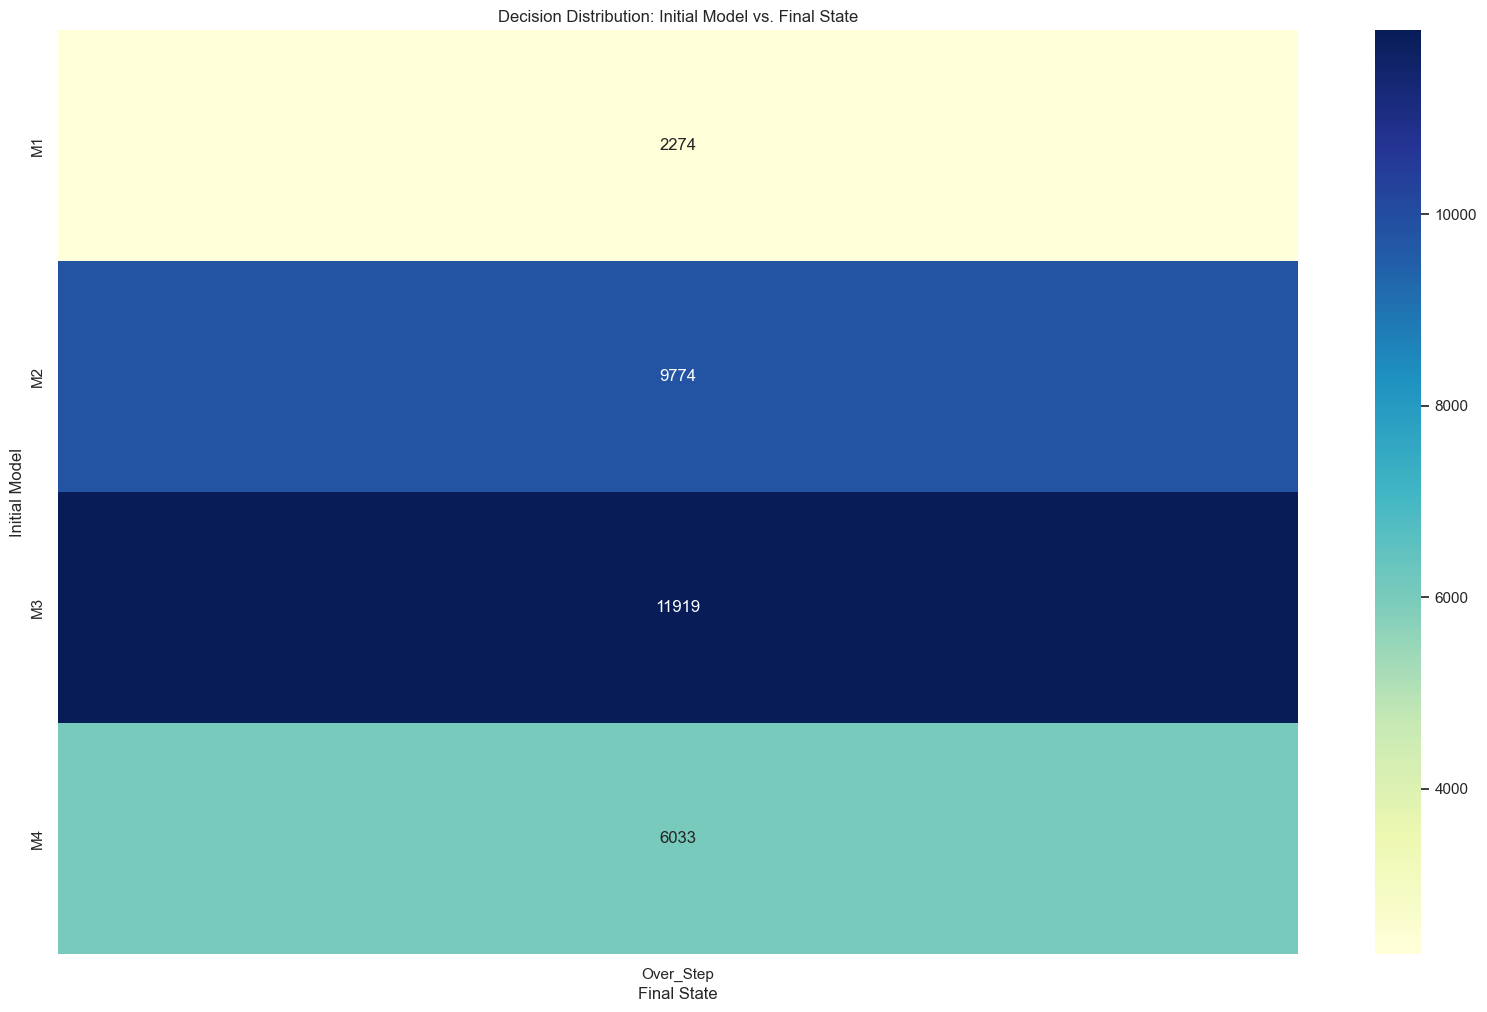

In [69]:
plt.figure(figsize=(20, 12))
decision_matrix = pd.crosstab(df['initial_model_type'], df['final_state'])
sns.heatmap(decision_matrix, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Decision Distribution: Initial Model vs. Final State")
plt.xlabel("Final State")
plt.ylabel("Initial Model")
plt.show()

初始模型和奖励之间的关系

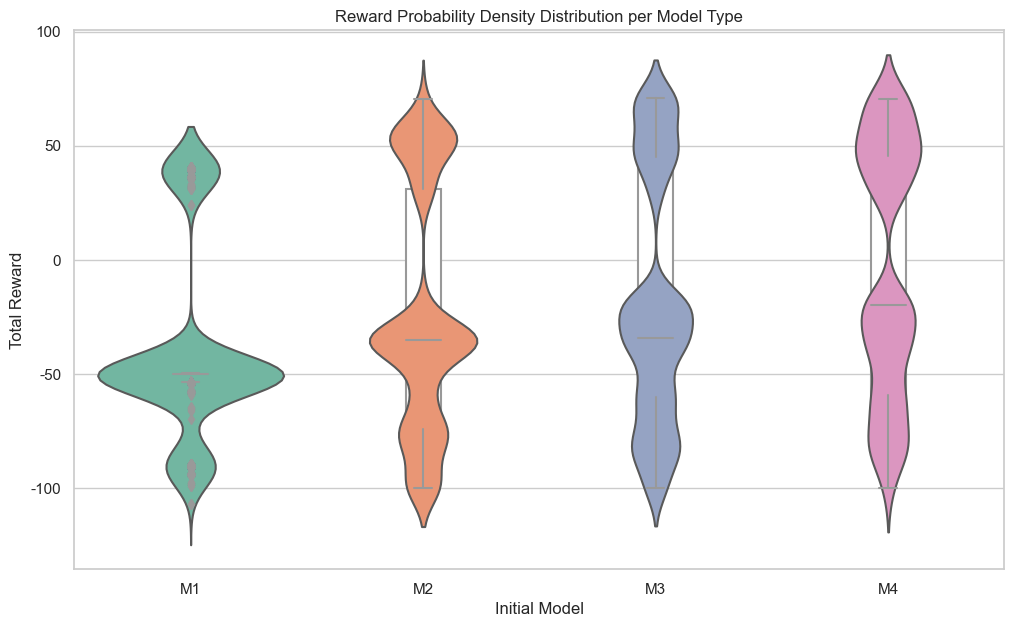

In [70]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='initial_model_type', y='total_reward', data=df,
               palette="Set2", order=['M1', 'M2', 'M3', 'M4'], inner=None, alpha=0.6)
sns.boxplot(x='initial_model_type', y='total_reward', data=df,
            width=0.15, color="white", order=['M1', 'M2', 'M3', 'M4'])
plt.title("Reward Probability Density Distribution per Model Type")
plt.xlabel("Initial Model")
plt.ylabel("Total Reward")
plt.show()

对输入输出进行编码

In [71]:
input_features = ['d', 'b', 'r', 'c']
# Encoding inputs for correlation calculation
df_encoded_inputs = df[input_features].copy()
le = LabelEncoder()
for col in input_features:
    df_encoded_inputs[col] = le.fit_transform(df_encoded_inputs[col].astype(str))

# Encoding final_state into actual outcomes
df_decisions = pd.get_dummies(df['final_state'], prefix='Result')

# Combine encoded inputs, numeric metrics, and expanded decisions
analysis_df = pd.concat([df_encoded_inputs, df_decisions, df[['total_steps', 'total_reward']]], axis=1)

输入与终端决策之间的关系

D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:198: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:203: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


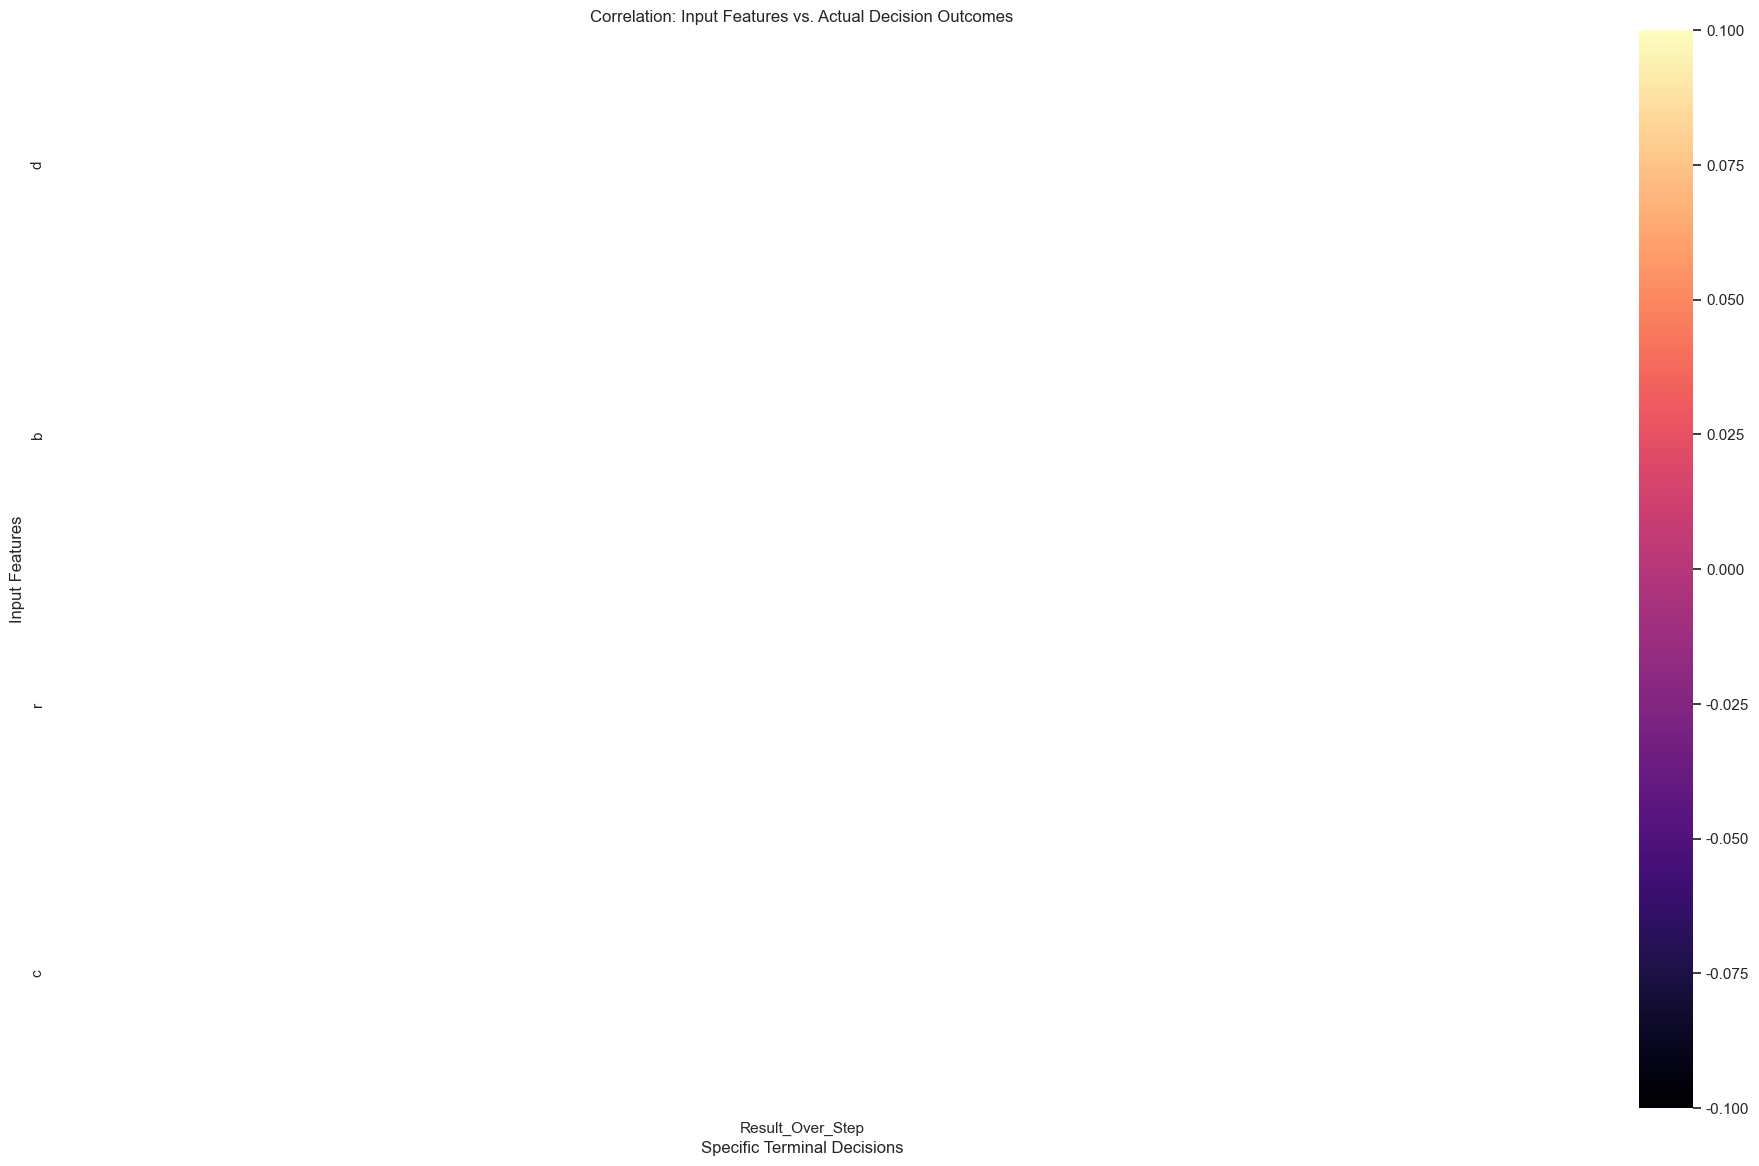

In [72]:
plt.figure(figsize=(24, 14))
# Calculate correlation and slice it to show Features vs. Specific Decisions
corr_matrix = analysis_df.corr()
sub_corr = corr_matrix.loc[input_features, df_decisions.columns]

sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)
plt.title("Correlation: Input Features vs. Actual Decision Outcomes")
plt.xlabel("Specific Terminal Decisions")
plt.ylabel("Input Features")
plt.show()

奖励与动作步数之间的关系

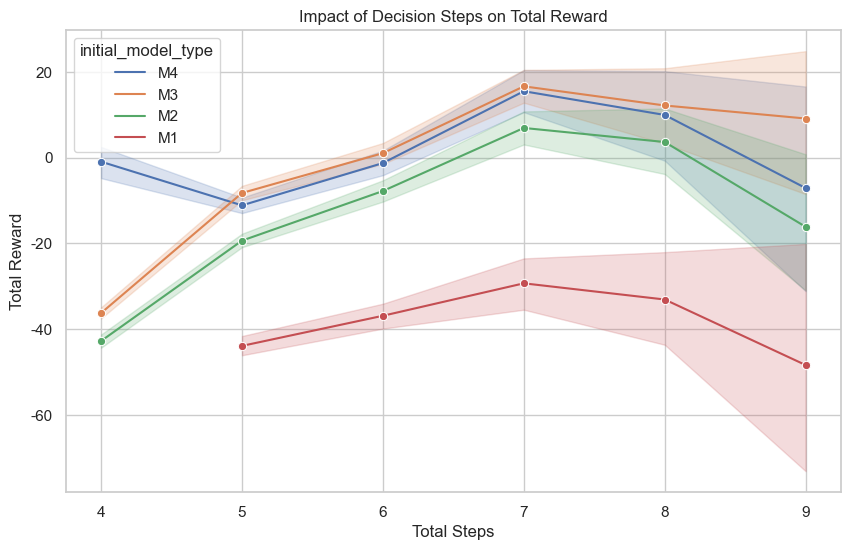

In [73]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='total_steps', y='total_reward', hue='initial_model_type', data=df, marker='o')
plt.title("Impact of Decision Steps on Total Reward")
plt.xlabel("Total Steps")
plt.ylabel("Total Reward")
plt.show()

那些输入导致Reject

--- d 在 Reject 中的分布 ---
Series([], Name: d, dtype: float64)
--- b 在 Reject 中的分布 ---
Series([], Name: b, dtype: float64)
--- c 在 Reject 中的分布 ---
Series([], Name: c, dtype: float64)
--- m 在 Reject 中的分布 ---
Series([], Name: m, dtype: float64)


D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:198: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:203: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


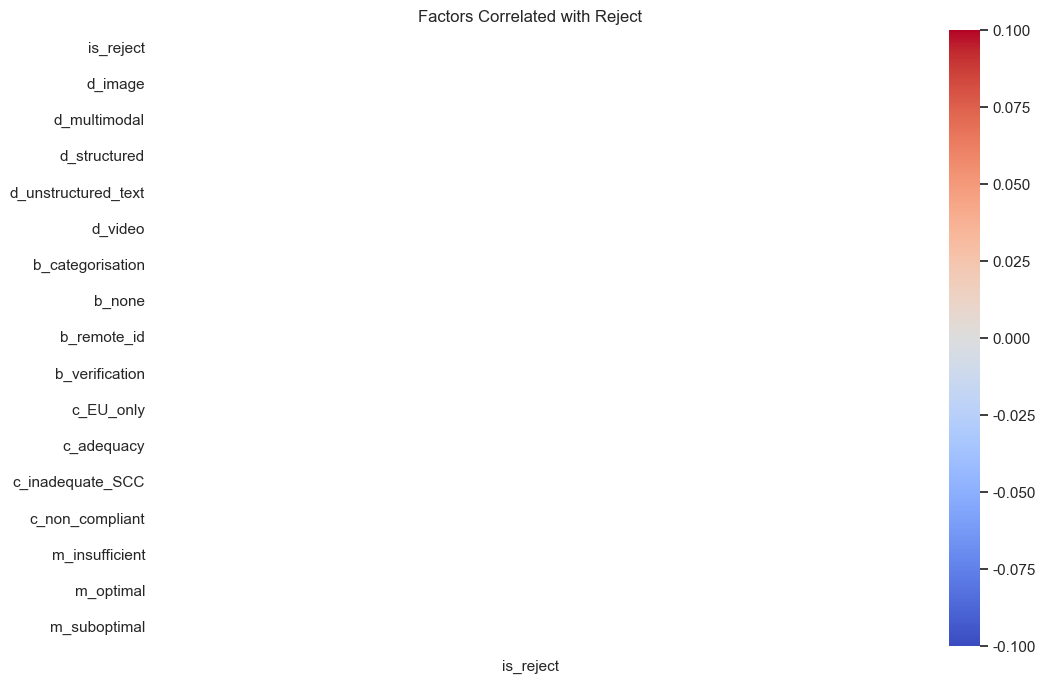

In [74]:
reject_df = df[df['final_state'] == 'Reject']

# 观察类别特征（例如 d, b, c）在 Reject 中的分布
features_to_check = ['d', 'b', 'c', 'm']
for col in features_to_check:
    print(f"--- {col} 在 Reject 中的分布 ---")
    print(reject_df[col].value_counts(normalize=True))

df['is_reject'] = (df['final_state'] == 'Reject').astype(int)
# 对类别变量进行 One-Hot 编码以便计算相关性
df_encoded = pd.get_dummies(df[['d', 'b', 'c', 'm', 'is_reject']])

# 计算相关性并绘图
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr()[['is_reject']].sort_values(by='is_reject', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Factors Correlated with Reject")
plt.show()

在拒绝的动作中，r和d之间的影响

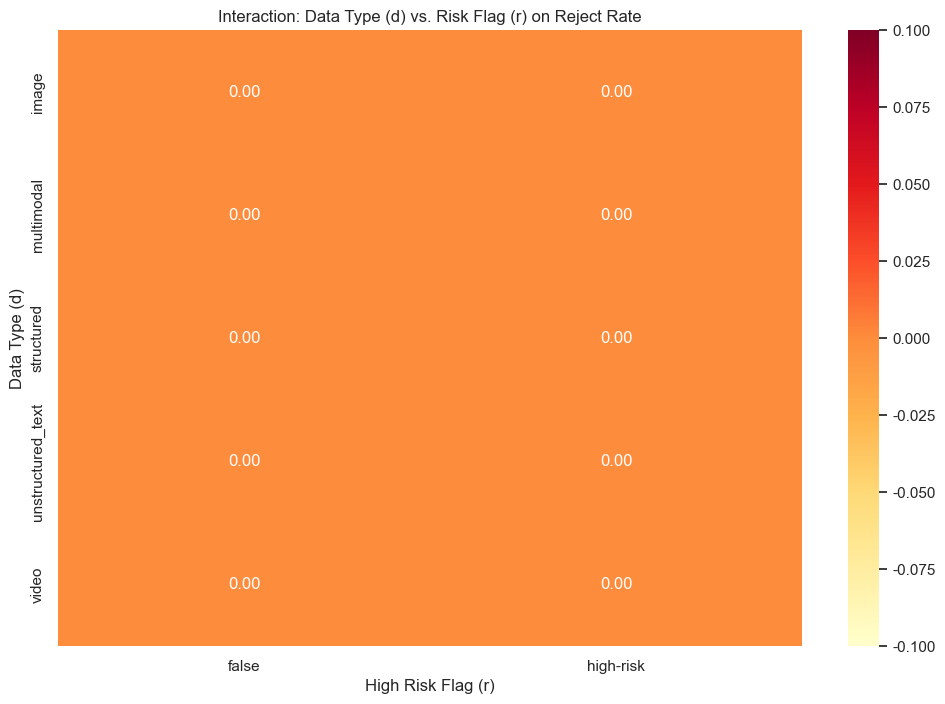

In [75]:
df['is_reject'] = (df['final_state'] == 'Reject').astype(int)
plt.figure(figsize=(12, 8))
interaction_pivot = df.pivot_table(index='d', columns='r', values='is_reject', aggfunc='mean')
sns.heatmap(interaction_pivot, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Interaction: Data Type (d) vs. Risk Flag (r) on Reject Rate")
plt.ylabel("Data Type (d)")
plt.xlabel("High Risk Flag (r)")
plt.show()

In [76]:
metrics_list = df['m_metrics'].apply(ast.literal_eval).tolist()
metrics_df = pd.DataFrame(metrics_list, columns=['m_loss', 'm_accuracy', 'm_recall', 'm_precision'])

# 3. 准备主分析表
# 选择基础特征 + 结果特征
base_features = ['d', 'b', 'r', 'c', 'm']
outcomes = ['total_steps', 'total_reward', 'final_state']
df_analysis = pd.concat([df[base_features], metrics_df, df[outcomes]], axis=1)

# 4. 数值化处理
le = LabelEncoder()
for col in ['d', 'b', 'r', 'c', 'm', 'final_state']:
    df_analysis[col] = le.fit_transform(df_analysis[col].astype(str))

# 5. 计算相关性矩阵
corr_matrix = df_analysis.corr()

if 'final_state' in df.columns:
    # --- 核心修改部分 ---
    # 使用 str.contains 检查是否包含 "Reject" 关键字
    # case=False 忽略大小写，na=False 处理空值
    is_reject = df['final_state'].str.contains('Reject', case=False, na=False).astype(int)

    # 重新构建用于计算相关性的临时 DataFrame
    # 排除不需要的列，并加入我们生成的 'Is_Reject' 列
    temp_analysis = df_analysis.drop(columns=['final_state', 'total_reward', 'total_steps'])
    temp_analysis['Is_Reject'] = is_reject

    # 计算相关性并提取 'Is_Reject' 这一列的结果
    reject_corr = temp_analysis.corr()['Is_Reject']

    print("-" * 30)
    print("Metrics correlation with 'Reject' decision (Unified):")
    # 显示指标与 Reject 状态的相关性
    print(reject_corr[['m_loss', 'm_accuracy', 'm_recall', 'm_precision']].sort_values(ascending=False))
    print("-" * 30)

------------------------------
Metrics correlation with 'Reject' decision (Unified):
m_loss        NaN
m_accuracy    NaN
m_recall      NaN
m_precision   NaN
Name: Is_Reject, dtype: float64
------------------------------


处理数据

In [77]:
input_features = ['d', 'b', 'r', 'c', 'm']
df_inputs = df[input_features].copy()
le = LabelEncoder()
for col in input_features:
    df_inputs[col] = le.fit_transform(df_inputs[col].astype(str))

# 将 final_state 展开为“真正的结果” (One-Hot Encoding)
# 这会生成 Decision_Accept_M1, Decision_Reject 等列
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

#  合并所有维度进行相关性计算
# 包含：输入基础特征 + 拆解后的指标 + 具体的决策结果 + 总奖励
df_full_analysis = pd.concat([df_inputs, metrics_df, df_decisions, df['total_reward'], df['total_steps']], axis=1)

# 提取相关性矩阵
corr_matrix = df_full_analysis.corr()

# 输入特征 + 性能指标 VS 具体决策结果 ---
# 我们只截取 [输入特征+指标] 作为纵轴，[决策结果] 作为横轴
plt.figure(figsize=(16, 10))

# 纵轴选择：基础特征 + 4个指标
y_axis_labels = input_features + ['m_loss', 'm_accuracy', 'm_recall', 'm_precision']
# 横轴选择：所有 Decision_ 开头的列
x_axis_labels = [col for col in df_decisions.columns]

# 提取子矩阵
sub_corr_matrix = corr_matrix.loc[y_axis_labels, x_axis_labels]

<Figure size 1600x1000 with 0 Axes>

所有输入与终端决策相关度

D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:198: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:203: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


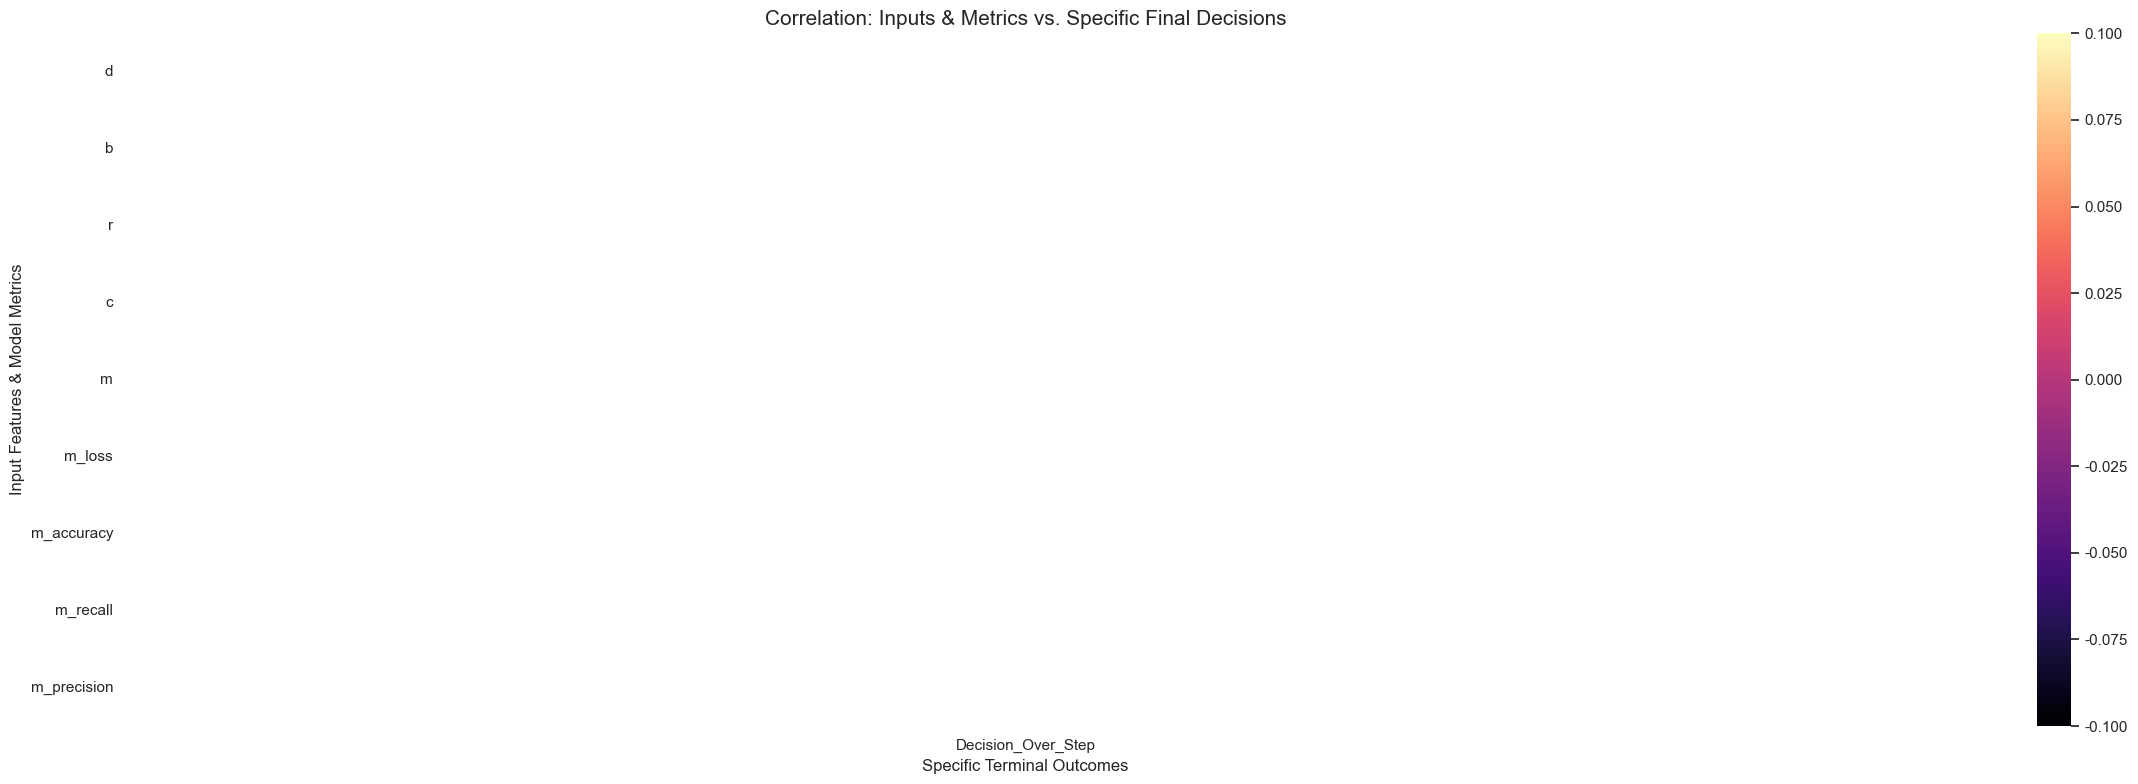

In [78]:
# 增加 figsize。因为你的 X 轴列数非常多，建议宽度给到 20 以上
plt.figure(figsize=(24, 8))

# annot_kws={"size": 8} 用于控制格子内数字的大小
sns.heatmap(sub_corr_matrix,
            annot=True,
            cmap="magma",
            fmt=".2f",
            linewidths=0.5,
            annot_kws={"size": 8}) # 调小数字字体

plt.title("Correlation: Inputs & Metrics vs. Specific Final Decisions", fontsize=15)
plt.xlabel("Specific Terminal Outcomes", fontsize=12)
plt.ylabel("Input Features & Model Metrics", fontsize=12)

# 自动调整布局，防止标签切断
plt.tight_layout()
plt.show()

全部变量相关度

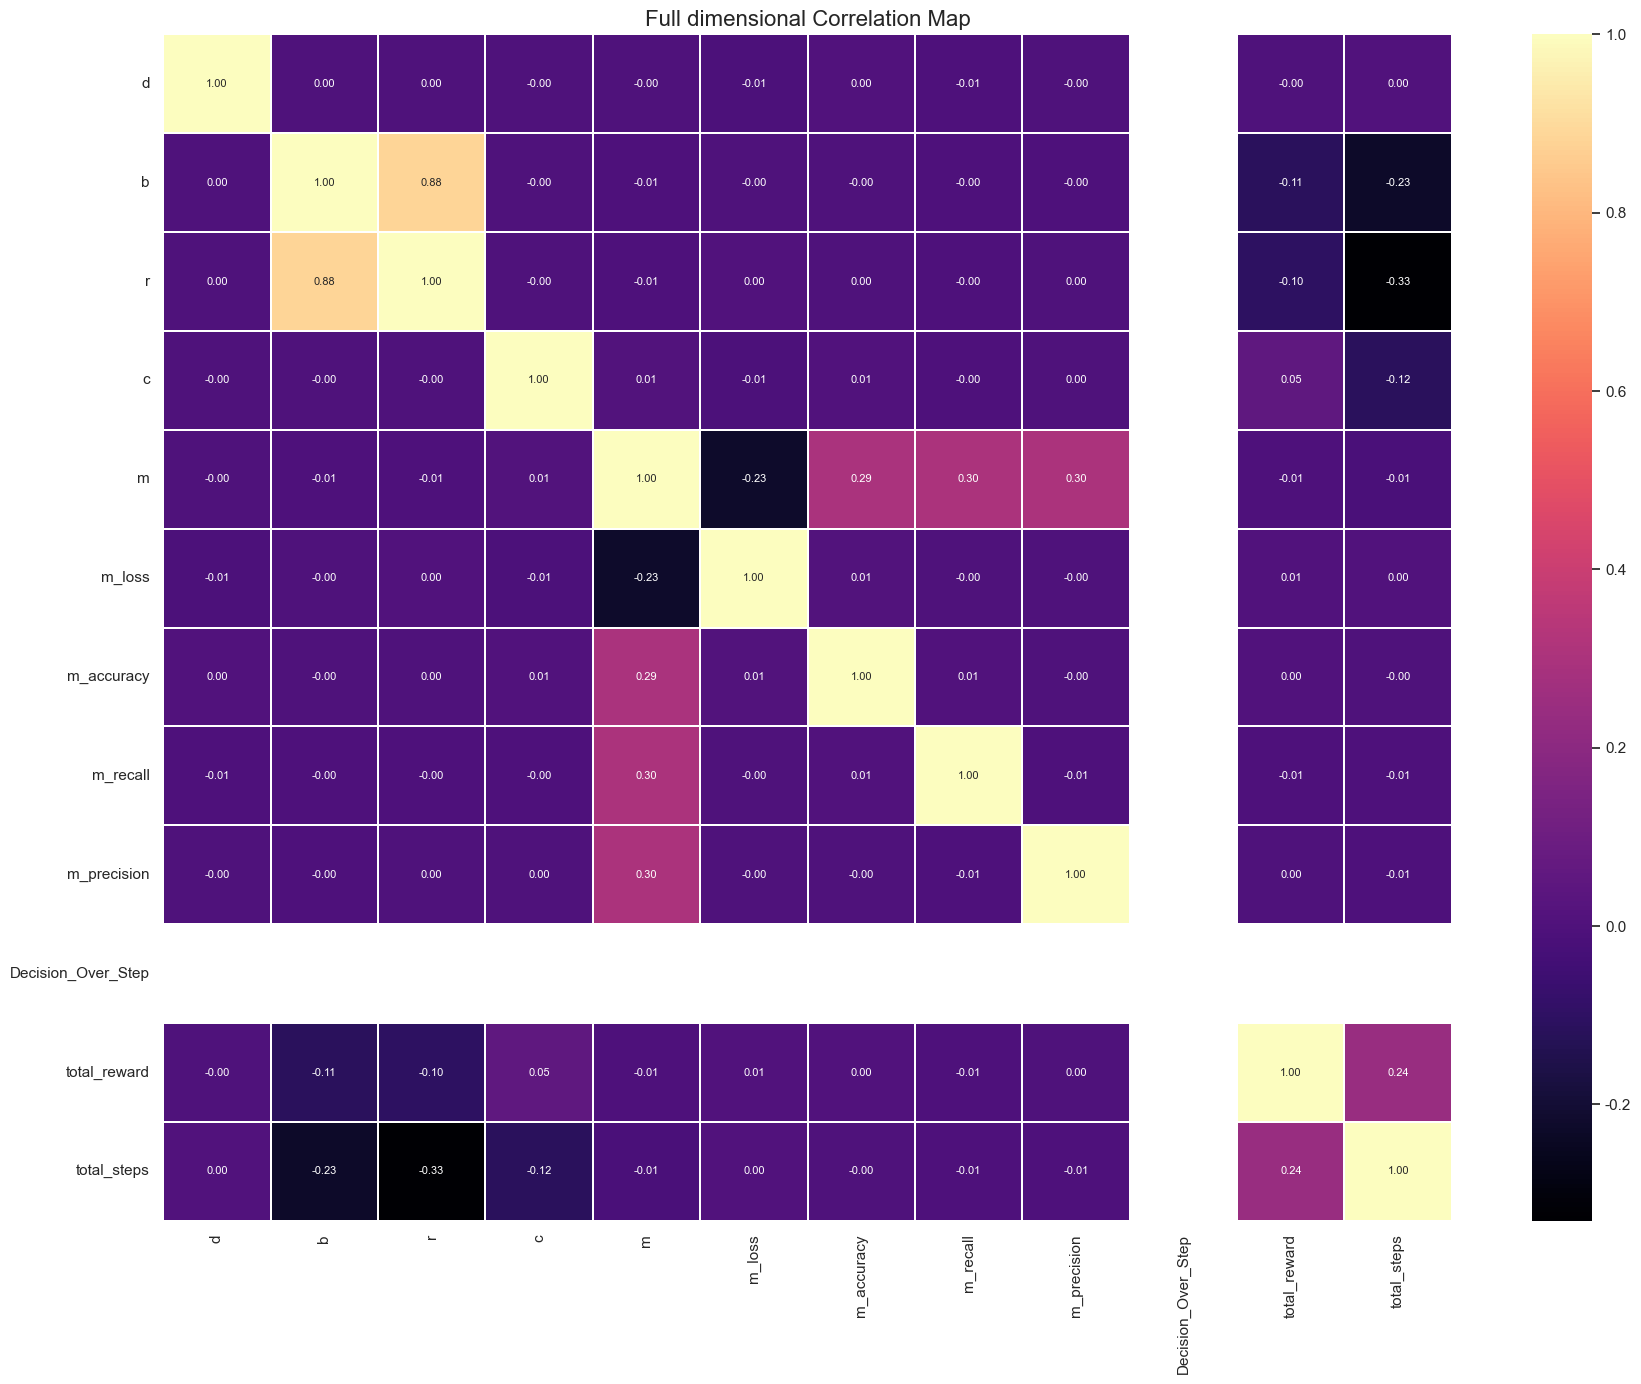

In [79]:
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, cmap="magma", fmt=".2f", linewidths=0.3, annot_kws={"size": 8})
plt.title("Full dimensional Correlation Map", fontsize=16)
plt.tight_layout()
plt.show()


In [80]:
print("-" * 30)
print("Decision Outcome Distribution:")
print(df['final_state'].value_counts())
print("-" * 30)

------------------------------
Decision Outcome Distribution:
Over_Step    30000
Name: final_state, dtype: int64
------------------------------


d值与终端决策之间的关系

D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:198: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:203: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


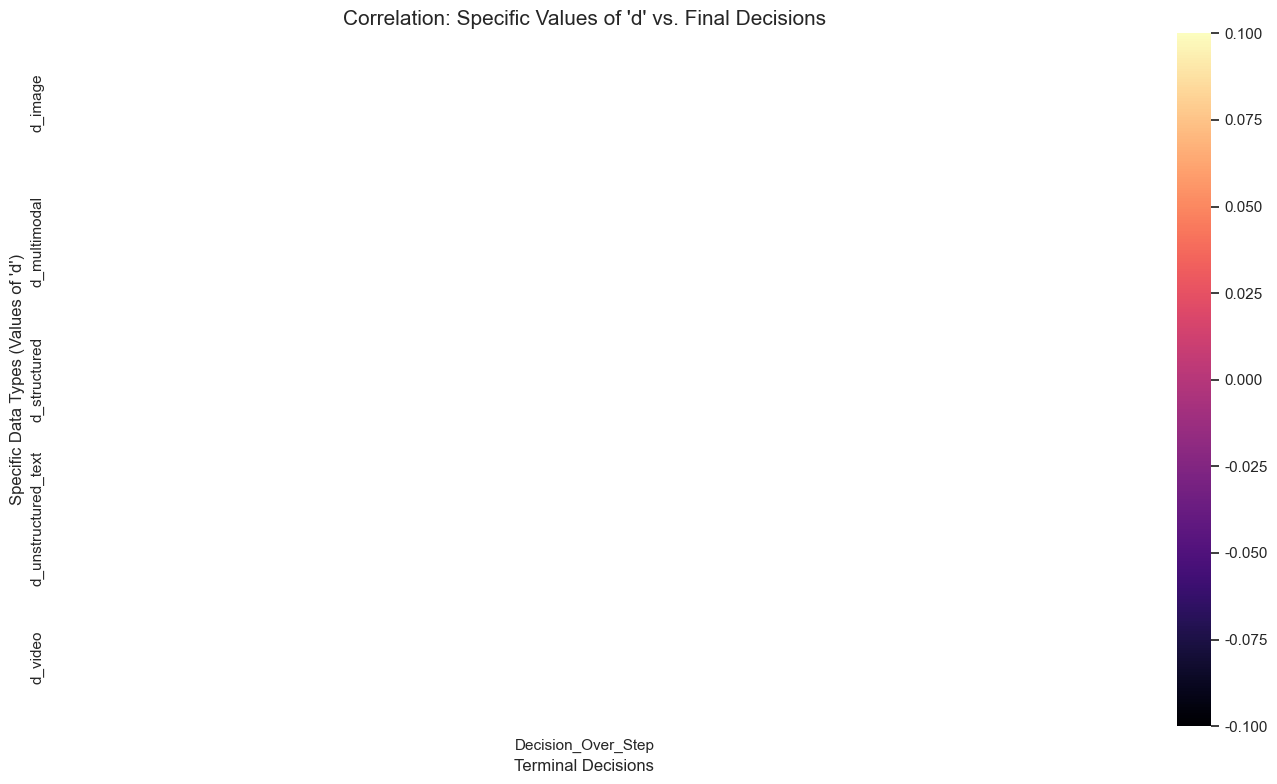

In [81]:
sns.set_theme(style="whitegrid")

#将特征 'd' 展开为具体数值列 (One-Hot)
df_d_values = pd.get_dummies(df['d'], prefix='d')
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

# 我们只关注 d 的具体值与最终决策之间的关系
df_d_corr = pd.concat([df_d_values, df_decisions], axis=1)
corr_matrix = df_d_corr.corr()
sub_corr = corr_matrix.loc[df_d_values.columns, df_decisions.columns]


plt.figure(figsize=(14, 8))
sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)

plt.title("Correlation: Specific Values of 'd' vs. Final Decisions", fontsize=15)
plt.xlabel("Terminal Decisions", fontsize=12)
plt.ylabel("Specific Data Types (Values of 'd')", fontsize=12)
plt.tight_layout()
plt.show()

In [82]:
print("-" * 30)
print("Distribution of Decisions per Data Type (d):")
pivot_table = pd.crosstab(df['d'], df['final_state'], normalize='index') * 100
print(pivot_table.round(2).astype(str) + '%')
print("-" * 30)

------------------------------
Distribution of Decisions per Data Type (d):
final_state       Over_Step
d                          
image                100.0%
multimodal           100.0%
structured           100.0%
unstructured_text    100.0%
video                100.0%
------------------------------


d值和r值之间的关系 在Reject之间

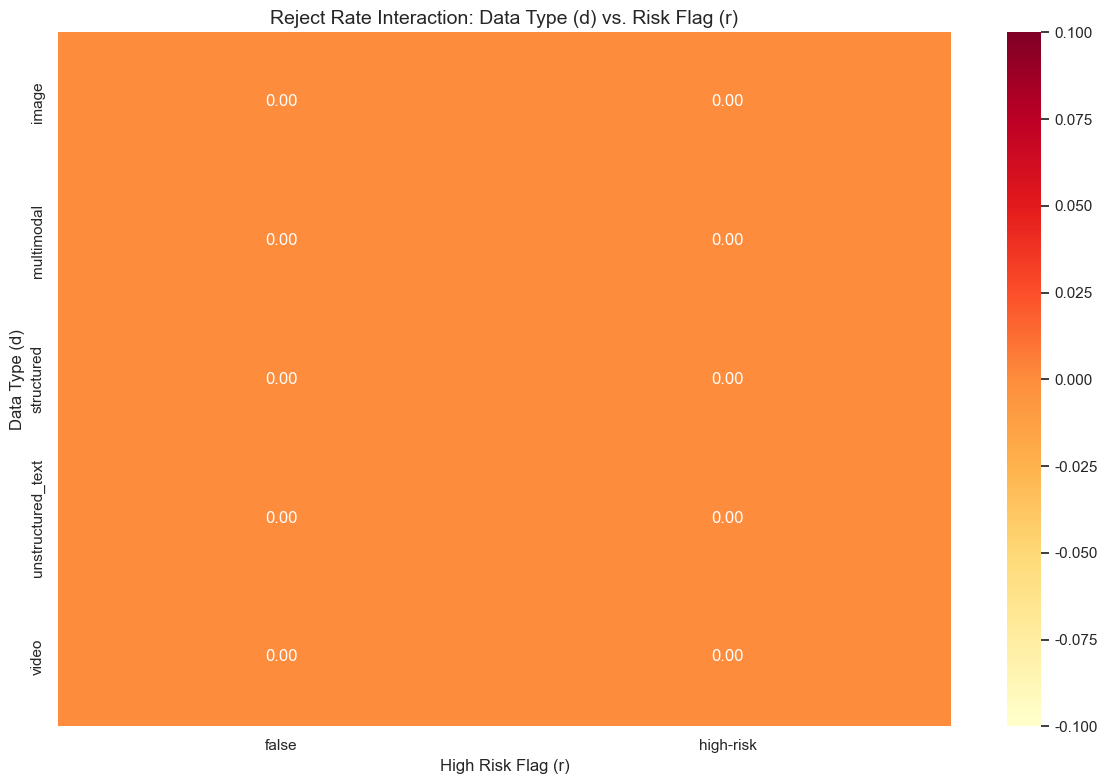

In [83]:
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False
# --- Analysis 1: Multi-Feature Interaction (Reject Rate Matrix) ---
# Observation: Interaction between Data Type (d) and Risk Level (r)
df['final_state'] = df['final_state'].replace({'M1': 'Reject', 'M2': 'Reject', 'M3': 'Reject'})
df['is_reject'] = (df['final_state'] == 'Reject').astype(int)

metrics_list = df['m_metrics'].apply(ast.literal_eval).tolist()
metrics_df = pd.DataFrame(metrics_list, columns=['m_loss', 'm_accuracy', 'm_recall', 'm_precision'])
df = pd.concat([df, metrics_df], axis=1)
plt.figure(figsize=(12, 8))
interaction_pivot = df.pivot_table(index='d', columns='r', values='is_reject', aggfunc='mean')

sns.heatmap(interaction_pivot, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Reject Rate Interaction: Data Type (d) vs. Risk Flag (r)", fontsize=14)
plt.ylabel("Data Type (d)")
plt.xlabel("High Risk Flag (r)")
plt.tight_layout()
plt.show()

b值与终端决策之间的关系

D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:198: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:203: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


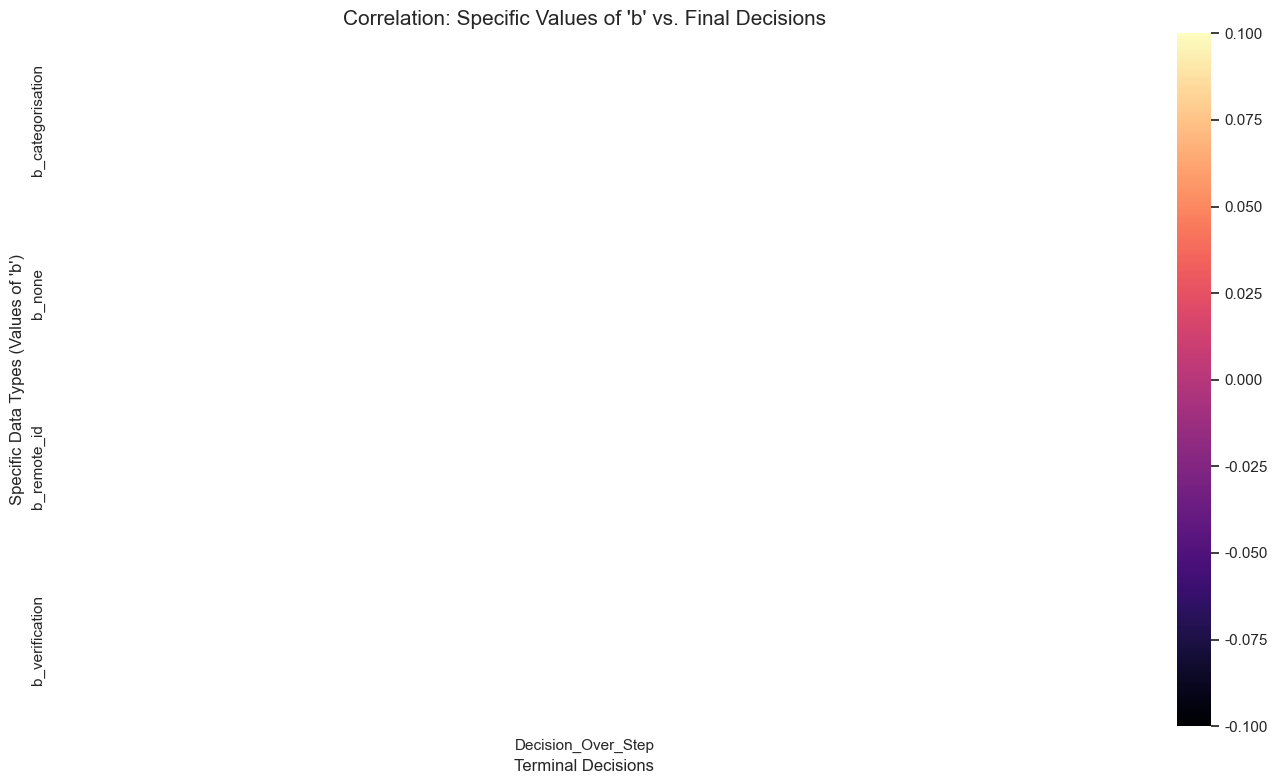

------------------------------
Distribution of Decisions per Data Type (b):
final_state    Over_Step
b                       
categorisation    100.0%
none              100.0%
remote_id         100.0%
verification      100.0%
------------------------------


In [84]:
sns.set_theme(style="whitegrid")

#将特征 'd' 展开为具体数值列 (One-Hot)
df_d_values = pd.get_dummies(df['b'], prefix='b')
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

# 我们只关注 d 的具体值与最终决策之间的关系
df_d_corr = pd.concat([df_d_values, df_decisions], axis=1)
corr_matrix = df_d_corr.corr()
sub_corr = corr_matrix.loc[df_d_values.columns, df_decisions.columns]


plt.figure(figsize=(14, 8))
sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)

plt.title("Correlation: Specific Values of 'b' vs. Final Decisions", fontsize=15)
plt.xlabel("Terminal Decisions", fontsize=12)
plt.ylabel("Specific Data Types (Values of 'b')", fontsize=12)
plt.tight_layout()
plt.show()
print("-" * 30)
print("Distribution of Decisions per Data Type (b):")
pivot_table = pd.crosstab(df['b'], df['final_state'], normalize='index') * 100
print(pivot_table.round(2).astype(str) + '%')
print("-" * 30)

c值与终端决策之间的关系

D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:198: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
D:\Software\Anaconda\lib\site-packages\seaborn\matrix.py:203: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


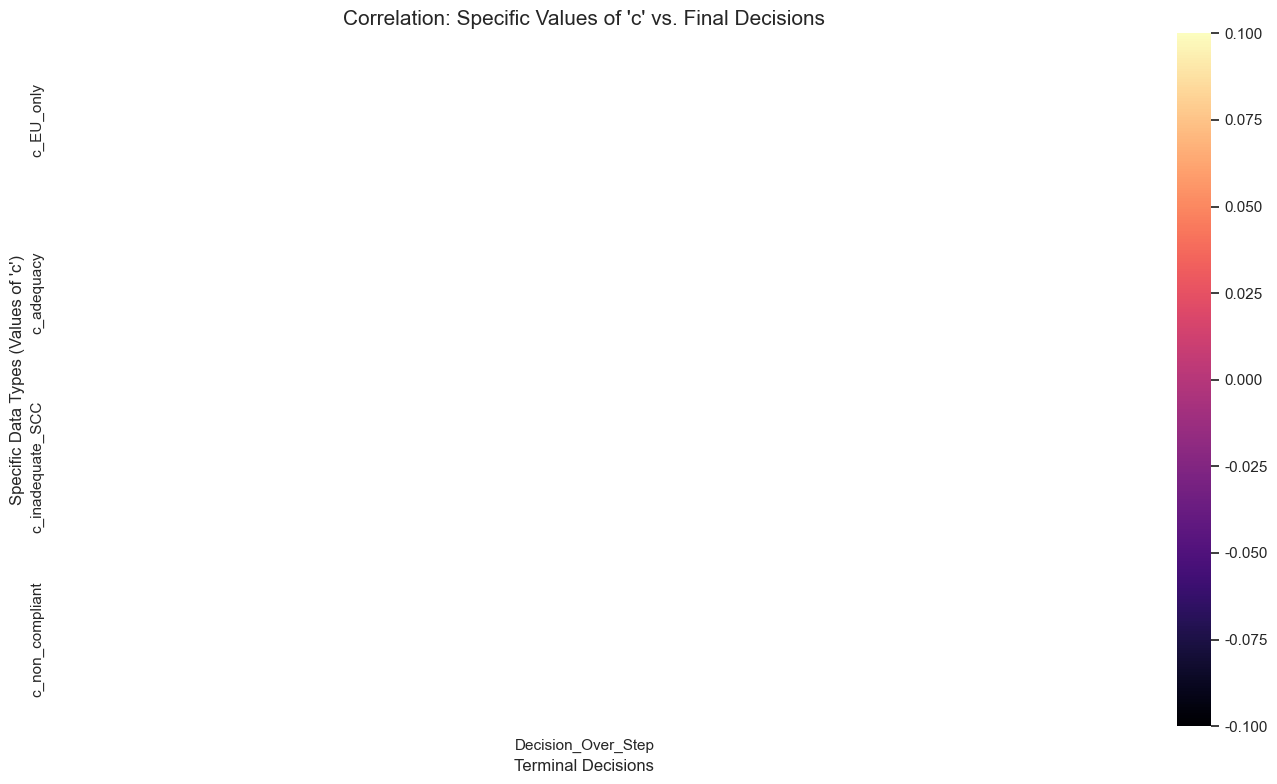

------------------------------
Distribution of Decisions per Data Type (c):
final_state    Over_Step
c                       
EU_only           100.0%
adequacy          100.0%
inadequate_SCC    100.0%
non_compliant     100.0%
------------------------------


In [85]:
sns.set_theme(style="whitegrid")

#将特征 'd' 展开为具体数值列 (One-Hot)
df_d_values = pd.get_dummies(df['c'], prefix='c')
df_decisions = pd.get_dummies(df['final_state'], prefix='Decision')

# 我们只关注 d 的具体值与最终决策之间的关系
df_d_corr = pd.concat([df_d_values, df_decisions], axis=1)
corr_matrix = df_d_corr.corr()
sub_corr = corr_matrix.loc[df_d_values.columns, df_decisions.columns]


plt.figure(figsize=(14, 8))
sns.heatmap(sub_corr, annot=True, cmap="magma", fmt=".2f", linewidths=0.5)

plt.title("Correlation: Specific Values of 'c' vs. Final Decisions", fontsize=15)
plt.xlabel("Terminal Decisions", fontsize=12)
plt.ylabel("Specific Data Types (Values of 'c')", fontsize=12)
plt.tight_layout()
plt.show()
print("-" * 30)
print("Distribution of Decisions per Data Type (c):")
pivot_table = pd.crosstab(df['c'], df['final_state'], normalize='index') * 100
print(pivot_table.round(2).astype(str) + '%')
print("-" * 30)

执行步数和最终决策以及初始模型的关系

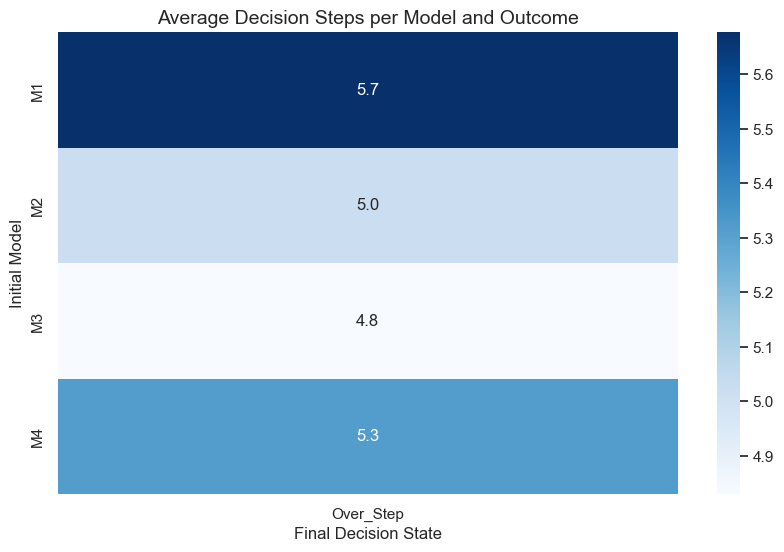

In [86]:
plt.figure(figsize=(10, 6))
step_summary = df.groupby(['initial_model_type', 'final_state'])['total_steps'].mean().unstack()
sns.heatmap(step_summary, annot=True, cmap="Blues", fmt=".1f")
plt.title("Average Decision Steps per Model and Outcome", fontsize=14)
plt.xlabel("Final Decision State")
plt.ylabel("Initial Model")
plt.show()

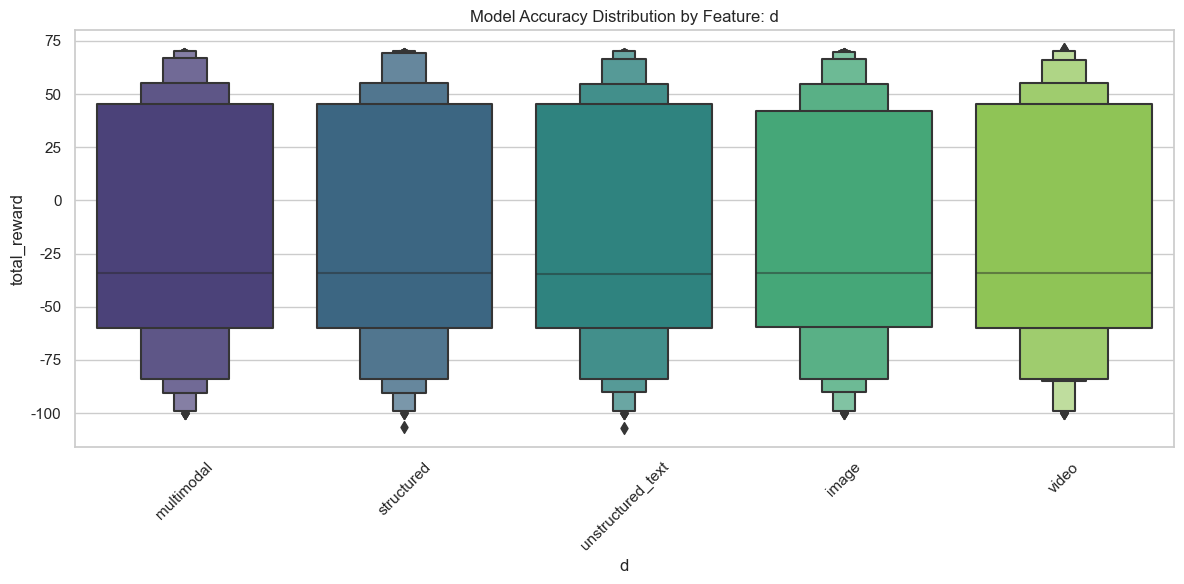

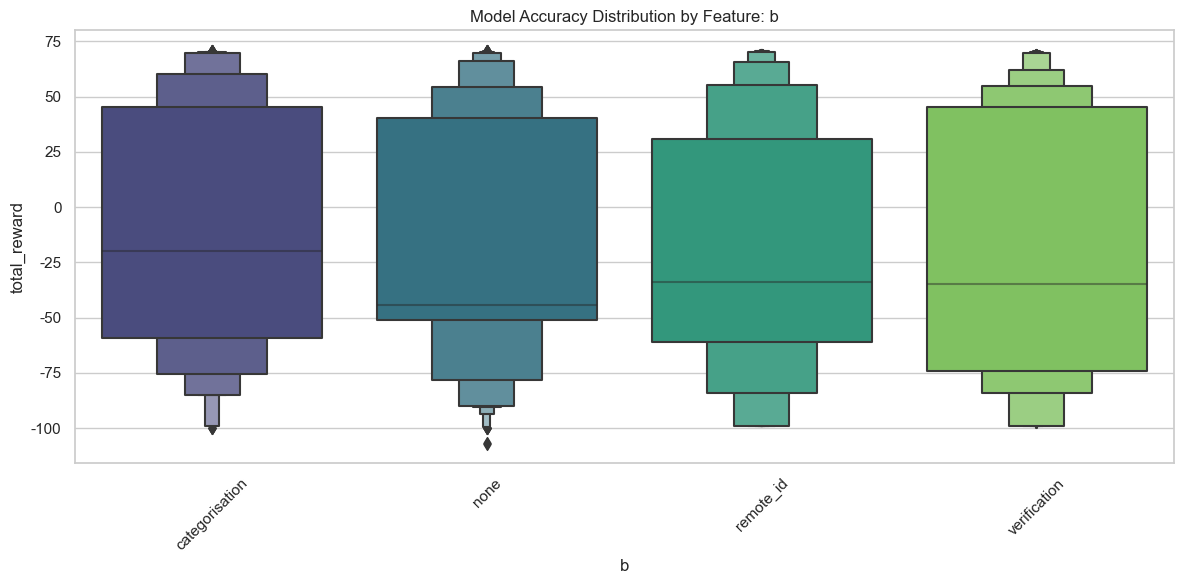

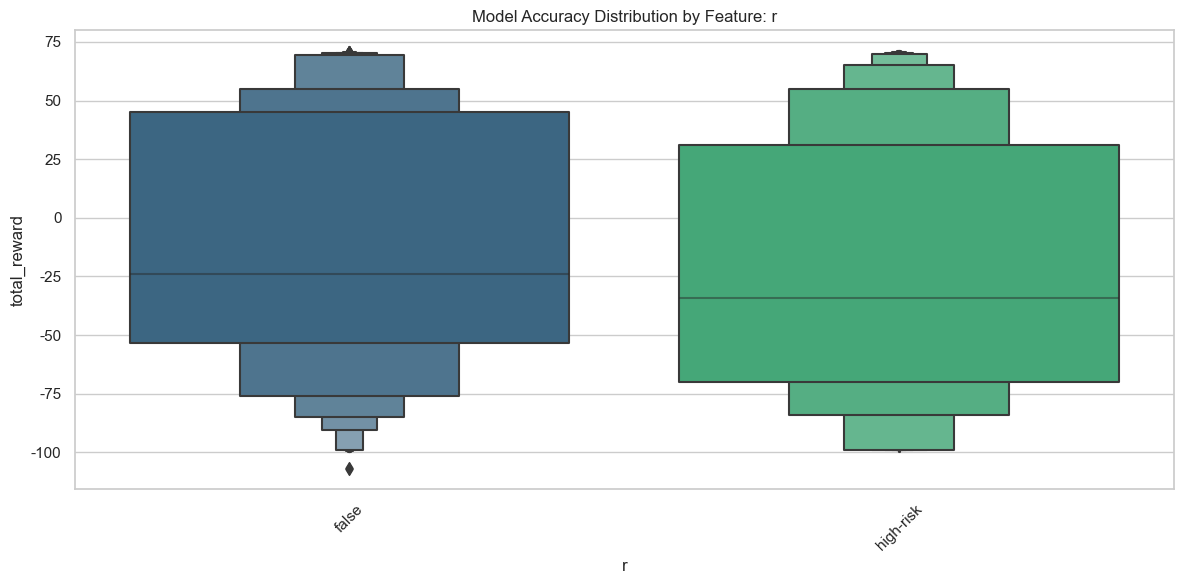

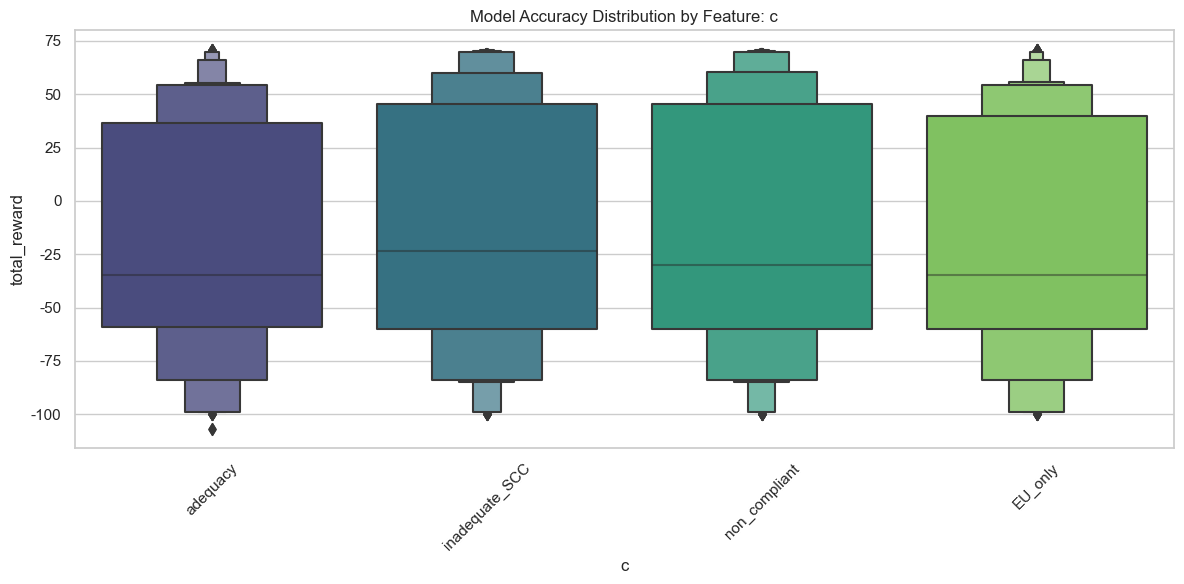

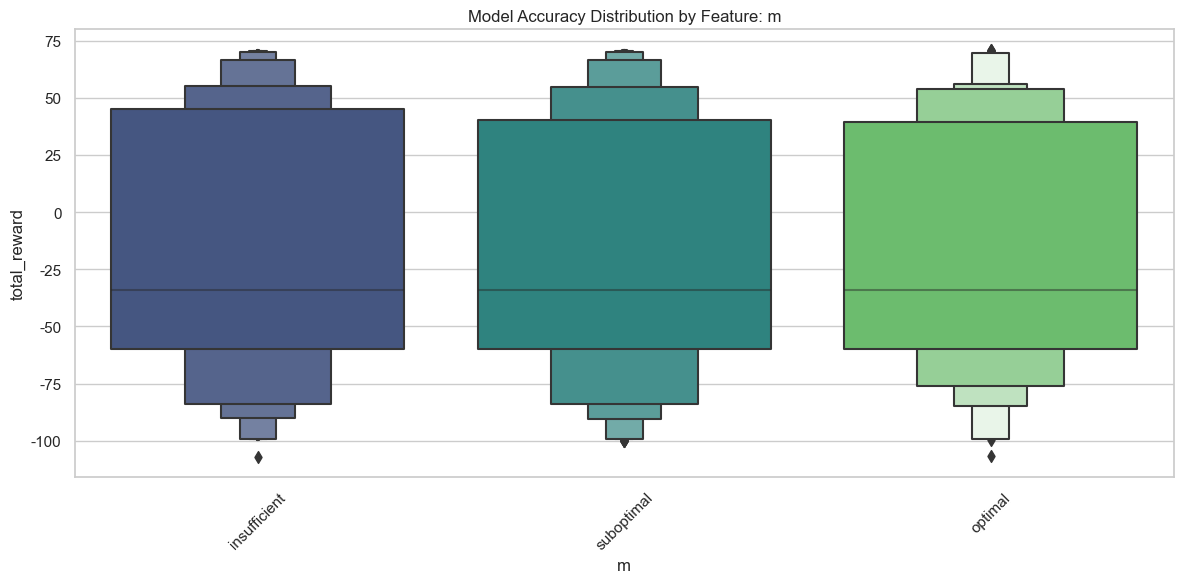

In [87]:
def plot_accuracy_analysis(df, features, label):
    """
    深度分析：针对每一个输入变量，分析其对 m_accuracy 的影响分布
    """
    for col in features:
        plt.figure(figsize=(12, 6))
        # 使用 Boxenplot 适合展示大规模数据的分布，比 Boxplot 更细致
        sns.boxenplot(x=col, y=label, data=df, palette="viridis")
        plt.title(f"Model Accuracy Distribution by Feature: {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
label='total_reward'
plot_accuracy_analysis(df, input_features, label)

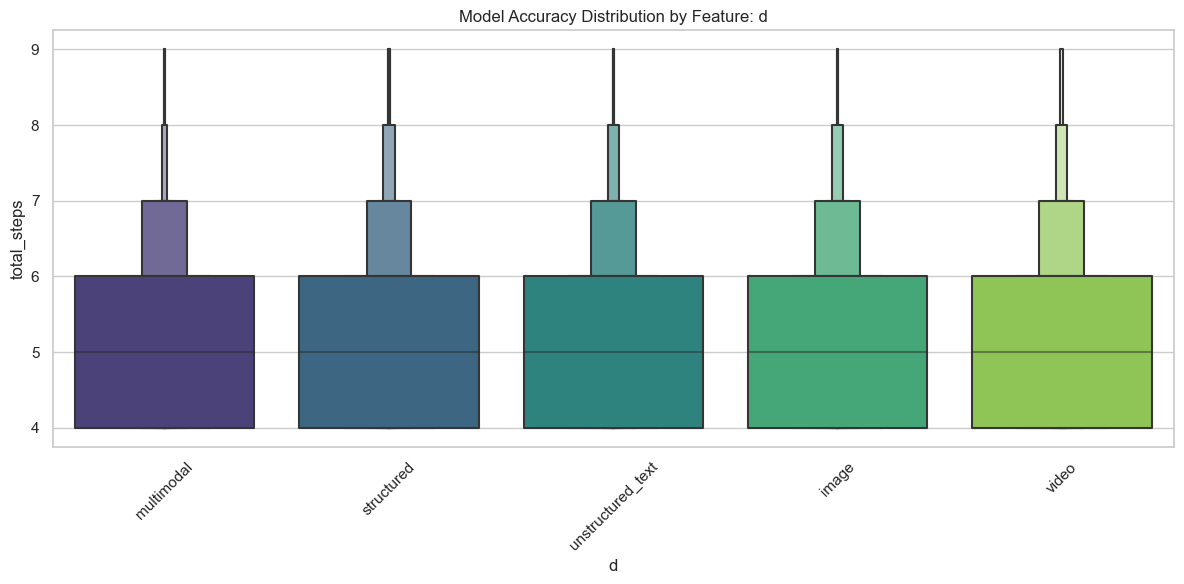

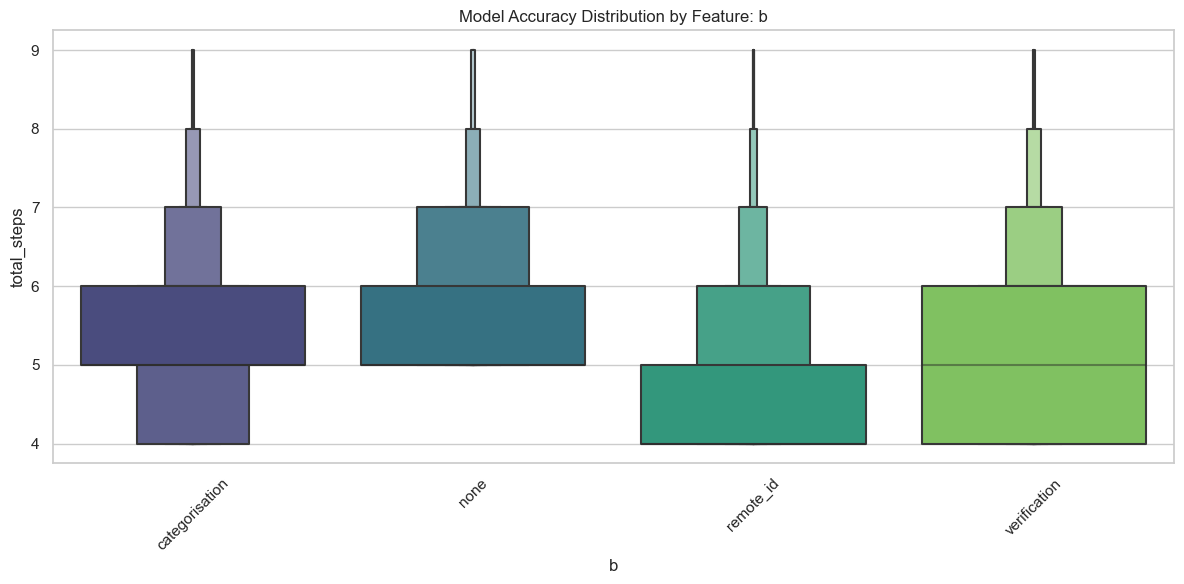

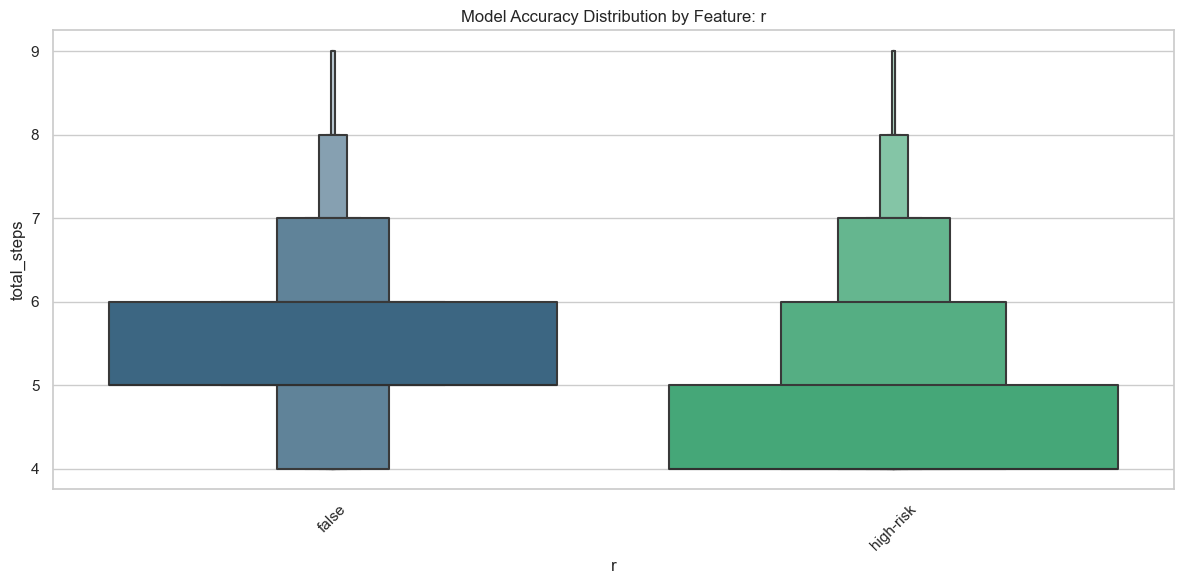

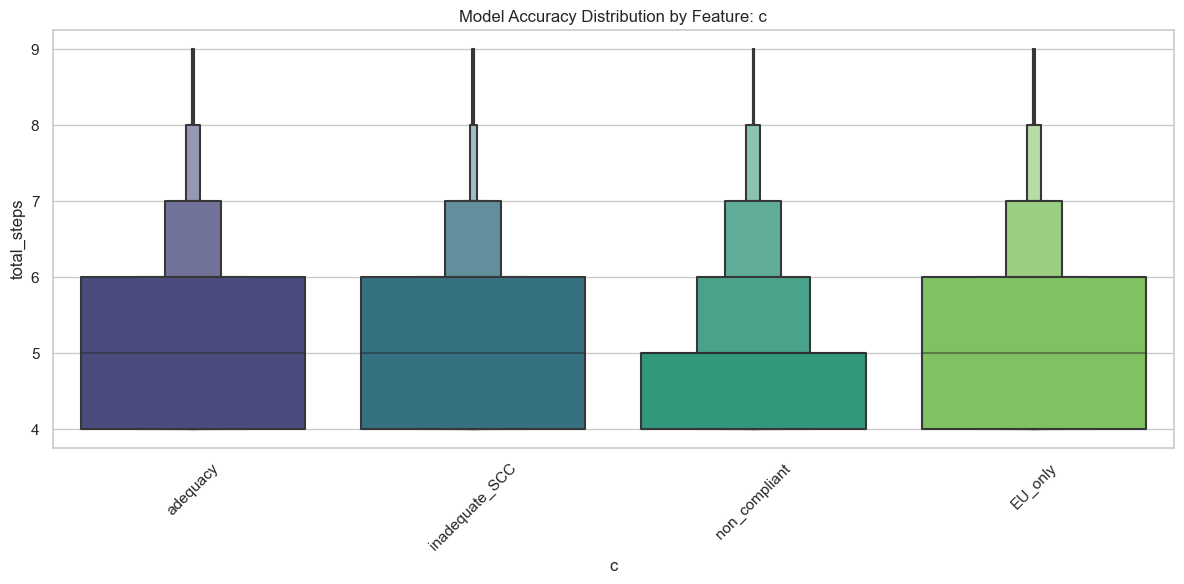

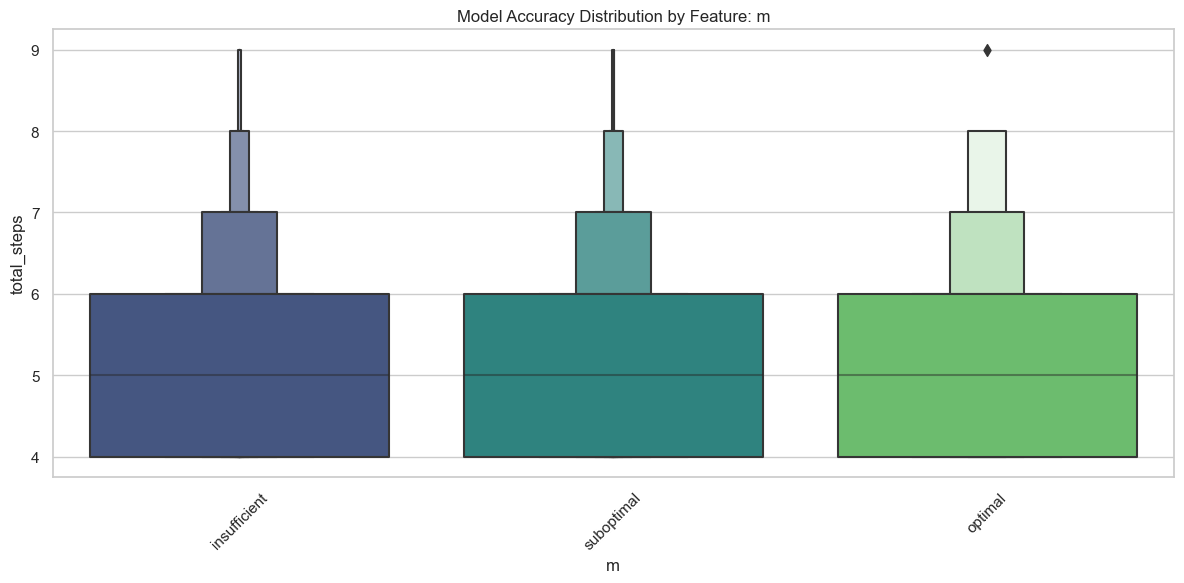

In [88]:
label='total_steps'
plot_accuracy_analysis(df, input_features, label)

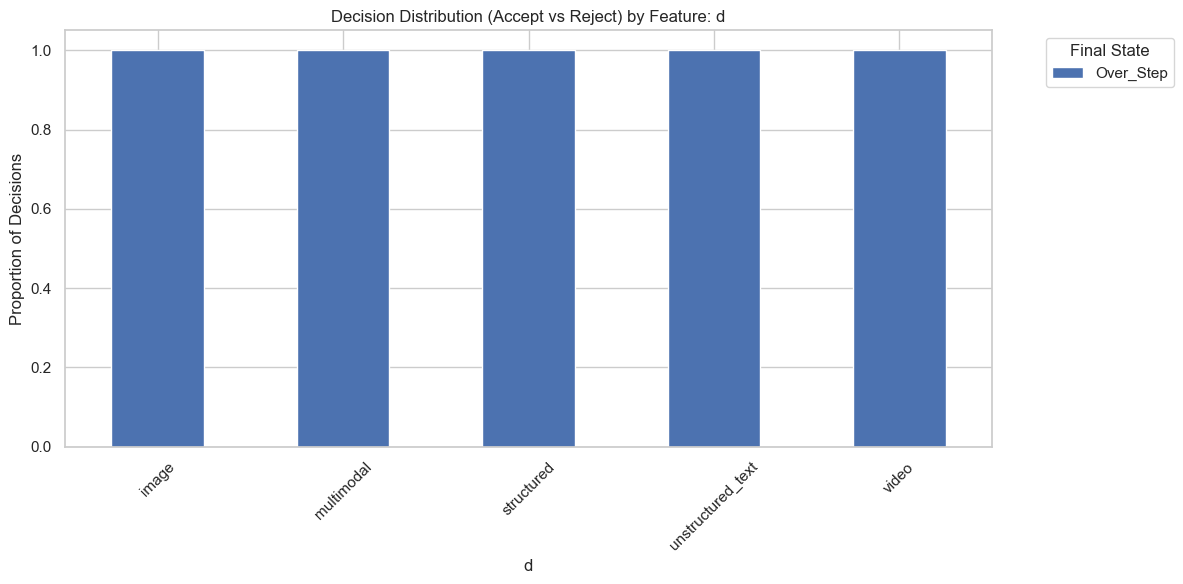

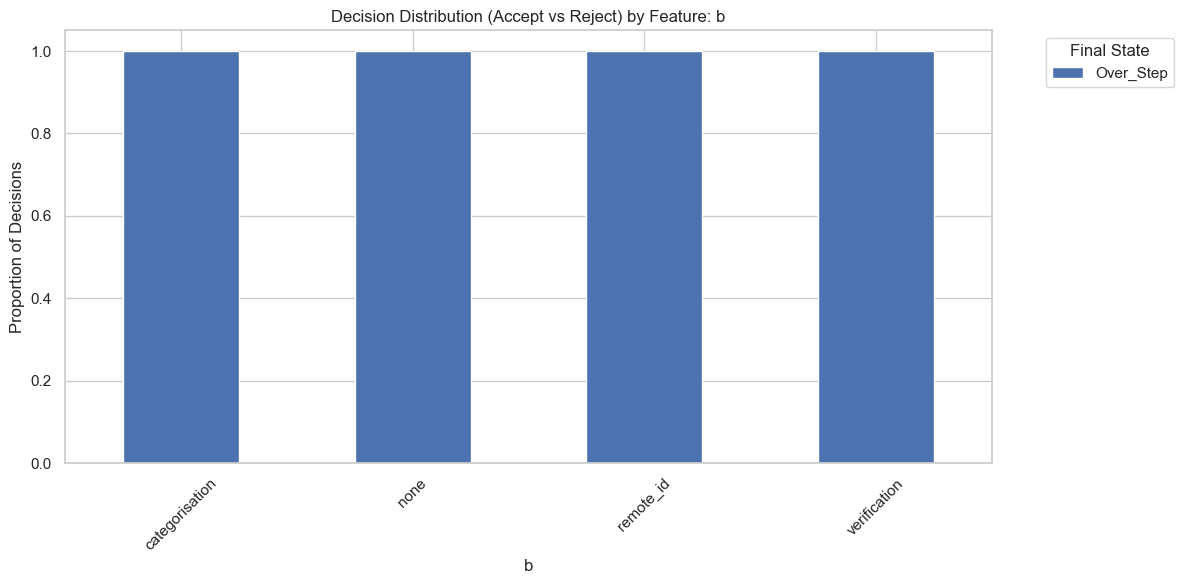

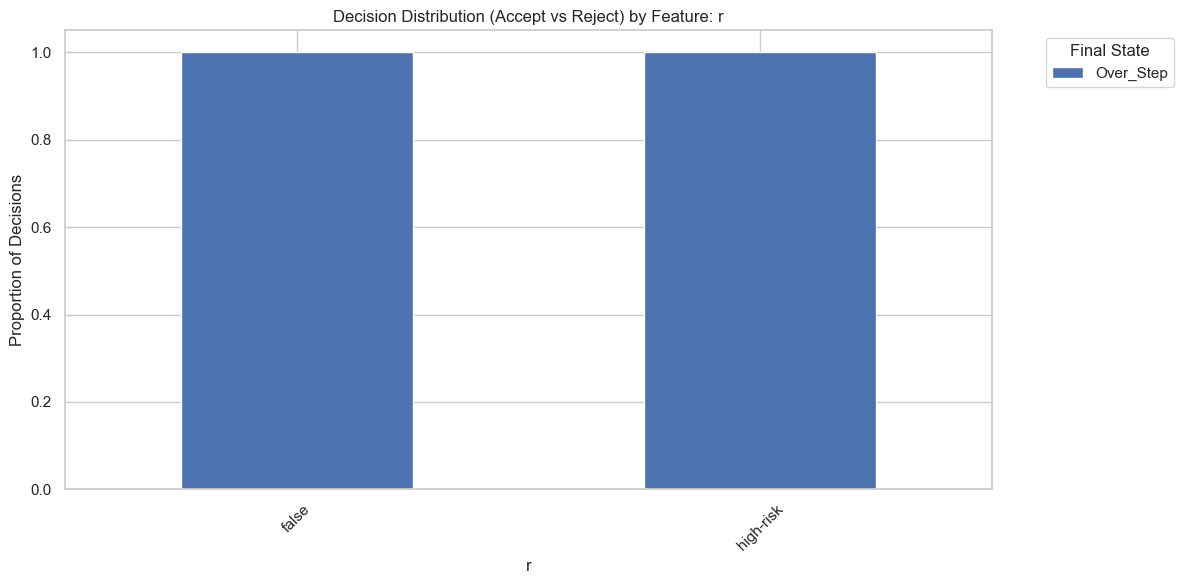

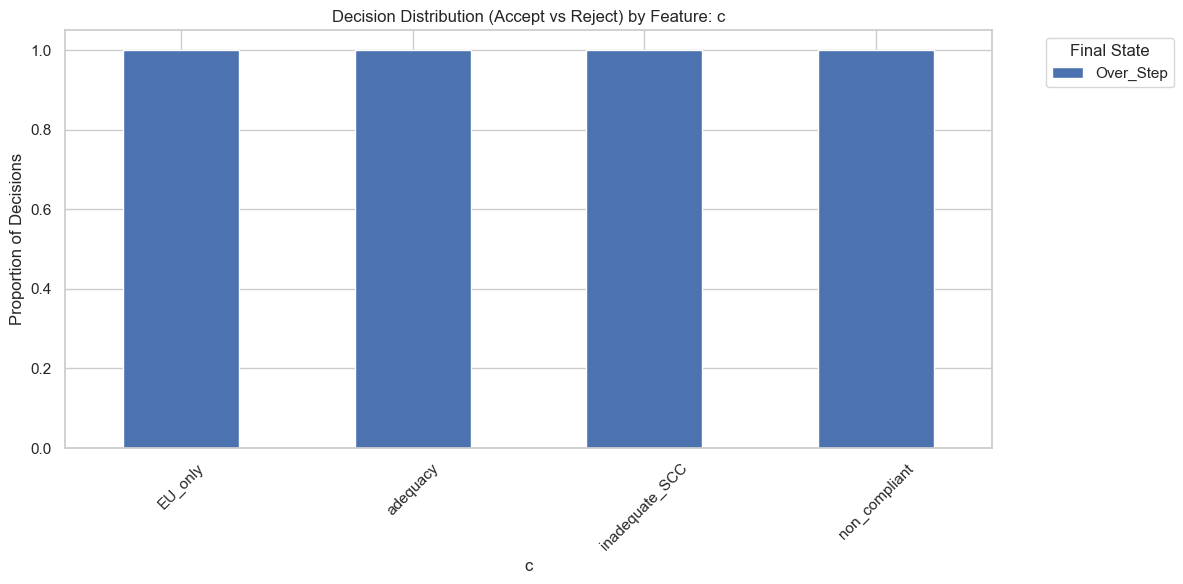

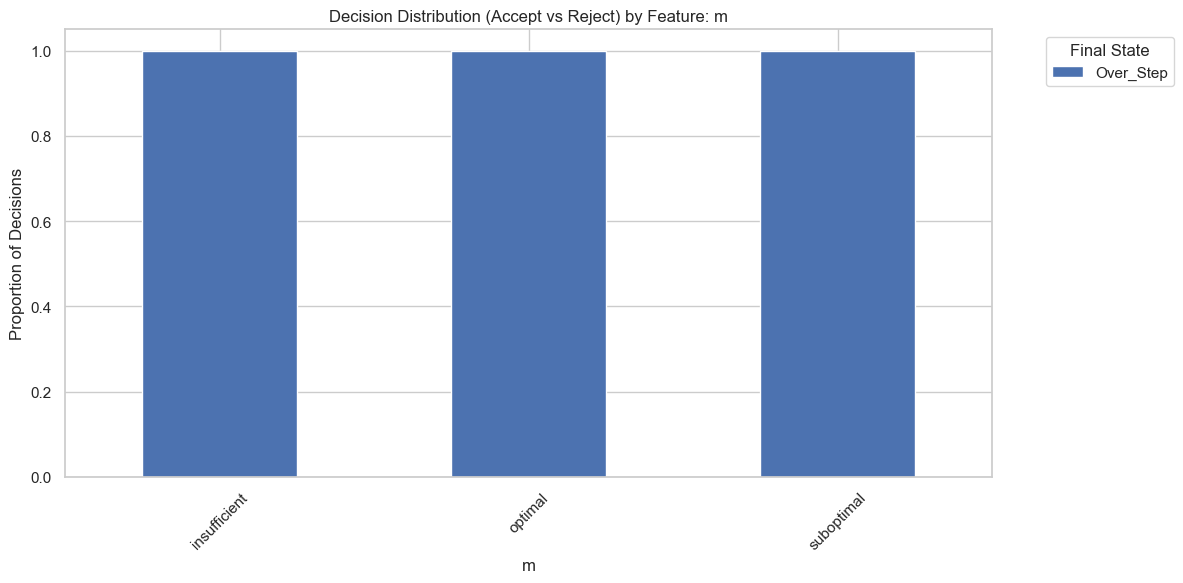

In [89]:
def plot_state_distribution_analysis(df, features, target_col='final_state'):
    """
    修改后：分析不同输入特征对最终决策（Final State）分布的影响
    """
    for col in features:
        plt.figure(figsize=(12, 6))

        # 1. 计算交叉表：特征 vs 状态
        cross_tab = pd.crosstab(df[col], df[target_col])

        # 2. 转换为百分比，以便对比分布比例
        cross_tab_prop = cross_tab.div(cross_tab.sum(1), axis=0)

        # 3. 绘制堆叠柱状图
        cross_tab_prop.plot(kind='bar', stacked=True, ax=plt.gca())

        plt.title(f"Decision Distribution (Accept vs Reject) by Feature: {col}")
        plt.ylabel("Proportion of Decisions")
        plt.xlabel(col)
        plt.legend(title="Final State", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 调用函数
plot_state_distribution_analysis(df, input_features)

决策树分析

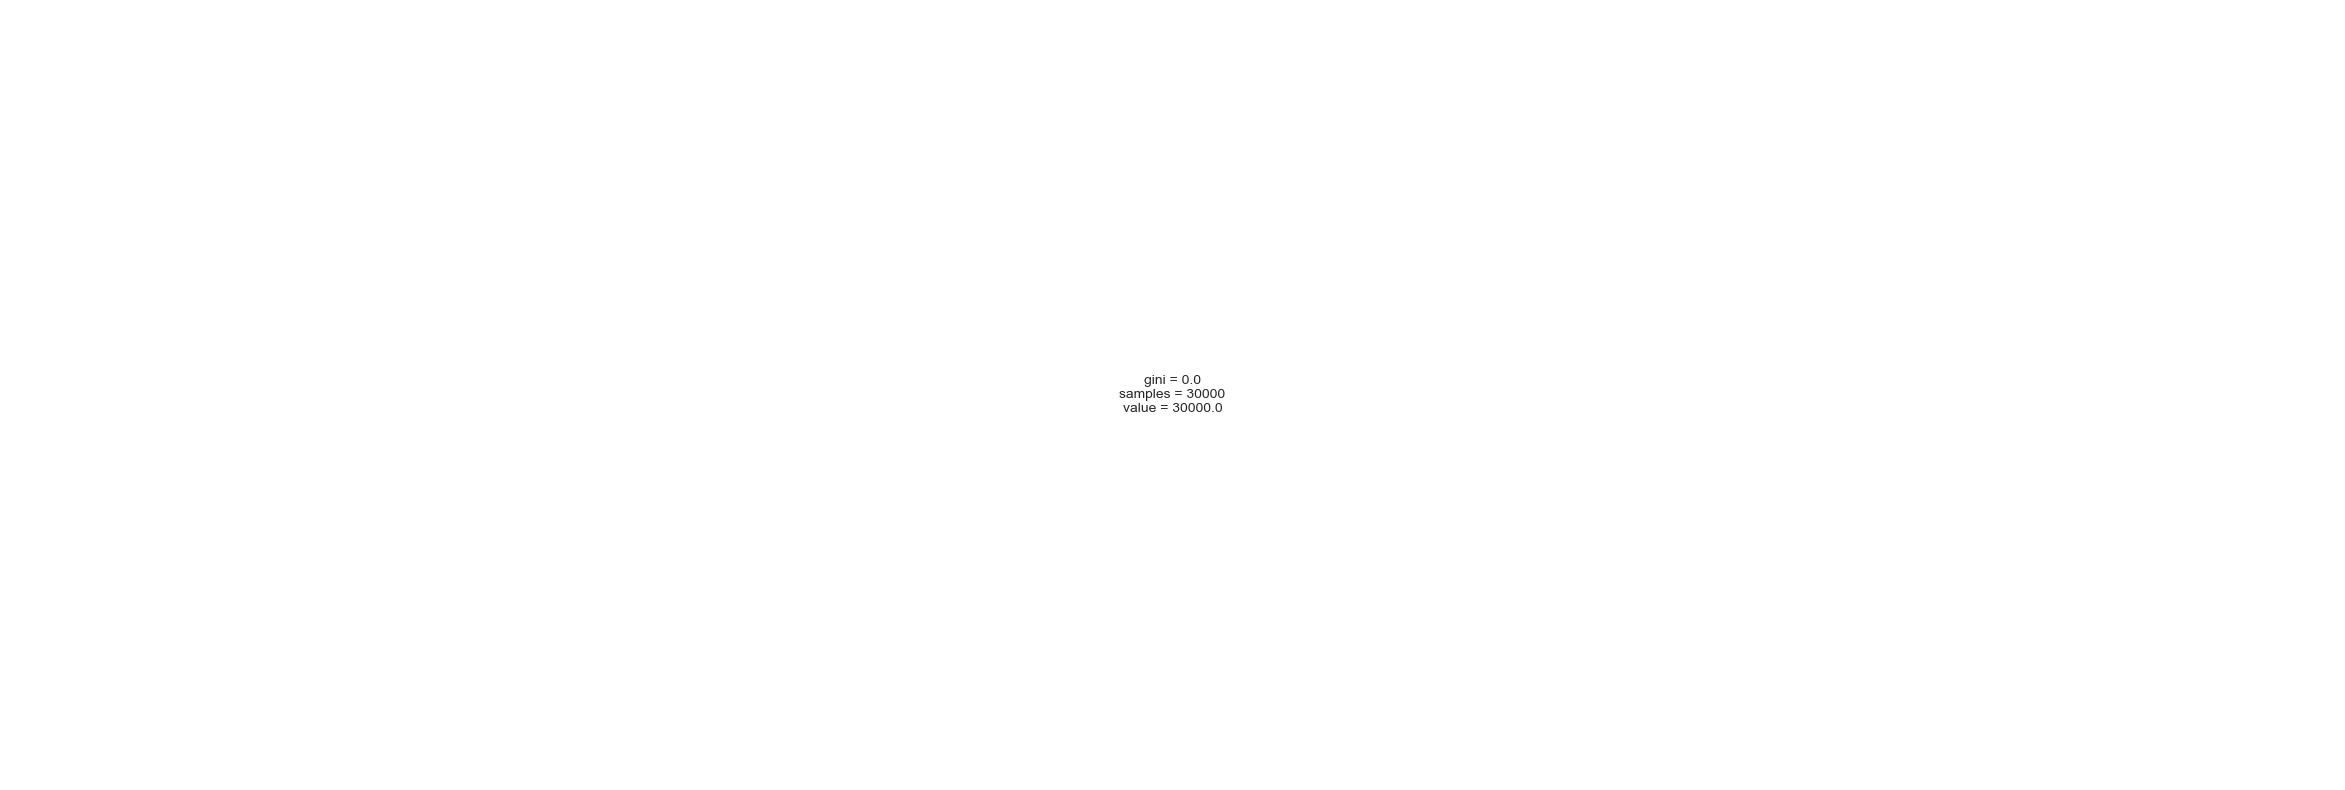

In [90]:
from matplotlib.colors import LinearSegmentedColormap
cmap_colors = ['#FAA26F', '#FEE199', '#B0D6A9']
custom_cmap = LinearSegmentedColormap.from_list("custom_rl", cmap_colors)
le_dict = {}
df_encoded = df_inputs.copy()
for col in input_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    le_dict[col] = le

# 2. 准备目标变量 (final_state)
le_y = LabelEncoder()
y = le_y.fit_transform(df['final_state'])

# 3. 训练决策树
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10)
dt.fit(df_encoded, y)

# 4. 可视化决策树
# plt.figure(figsize=(30, 10))
# # 1. 绘图并获取返回的 artist 对象
# artists = plot_tree(dt, feature_names=input_features,
#                     class_names=le_y.classes_,
#                     filled=True, rounded=True, fontsize=10)
#
# # 2. 自定义颜色填充逻辑
# # 我们将两类结局分配给色板的两端：
# # Accept -> 冷色调 (my_palette[0])
# # Reject -> 暖色调 (my_palette[-1])
#
# for artist in artists:
#     # 获取节点的文本内容来判断它属于哪一类
#     node_text = artist.get_text()
#
#     # 根据类别关键字修改颜色 (请确保 class_names 正确)
#     if "class = Accept" in node_text:
#         artist.set_bbox(dict(facecolor='#7BC0CD', edgecolor='black', boxstyle='round,pad=0.3'))
#     elif "class = Reject" in node_text:
#         artist.set_bbox(dict(facecolor='#ED8D5A', edgecolor='black', boxstyle='round,pad=0.3'))
#     else:
#         # 中间决策节点使用中性色
#         artist.set_bbox(dict(facecolor='#DBCB92', edgecolor='grey', boxstyle='round,pad=0.3'))
#
# plt.title("Decision Tree: Customized Color Scheme (Input Features vs Final State)", fontsize=15)
# plt.show()
plt.figure(figsize=(30, 10))
# plot_tree 本身不支持直接传 cmap，但我们可以修改生成的 patch
viz = plot_tree(dt, feature_names=input_features, class_names=le_y.classes_,
                filled=True, rounded=True, fontsize=10)

for artist in viz:
    # 获取节点的 Gini 指数或 Value 来决定颜色深浅
    # 这里通过 artist 关联的矩形框修改颜色
    if isinstance(artist, plt.Text):
        # 这里的逻辑可以根据你的具体类别索引进一步微调
        pass

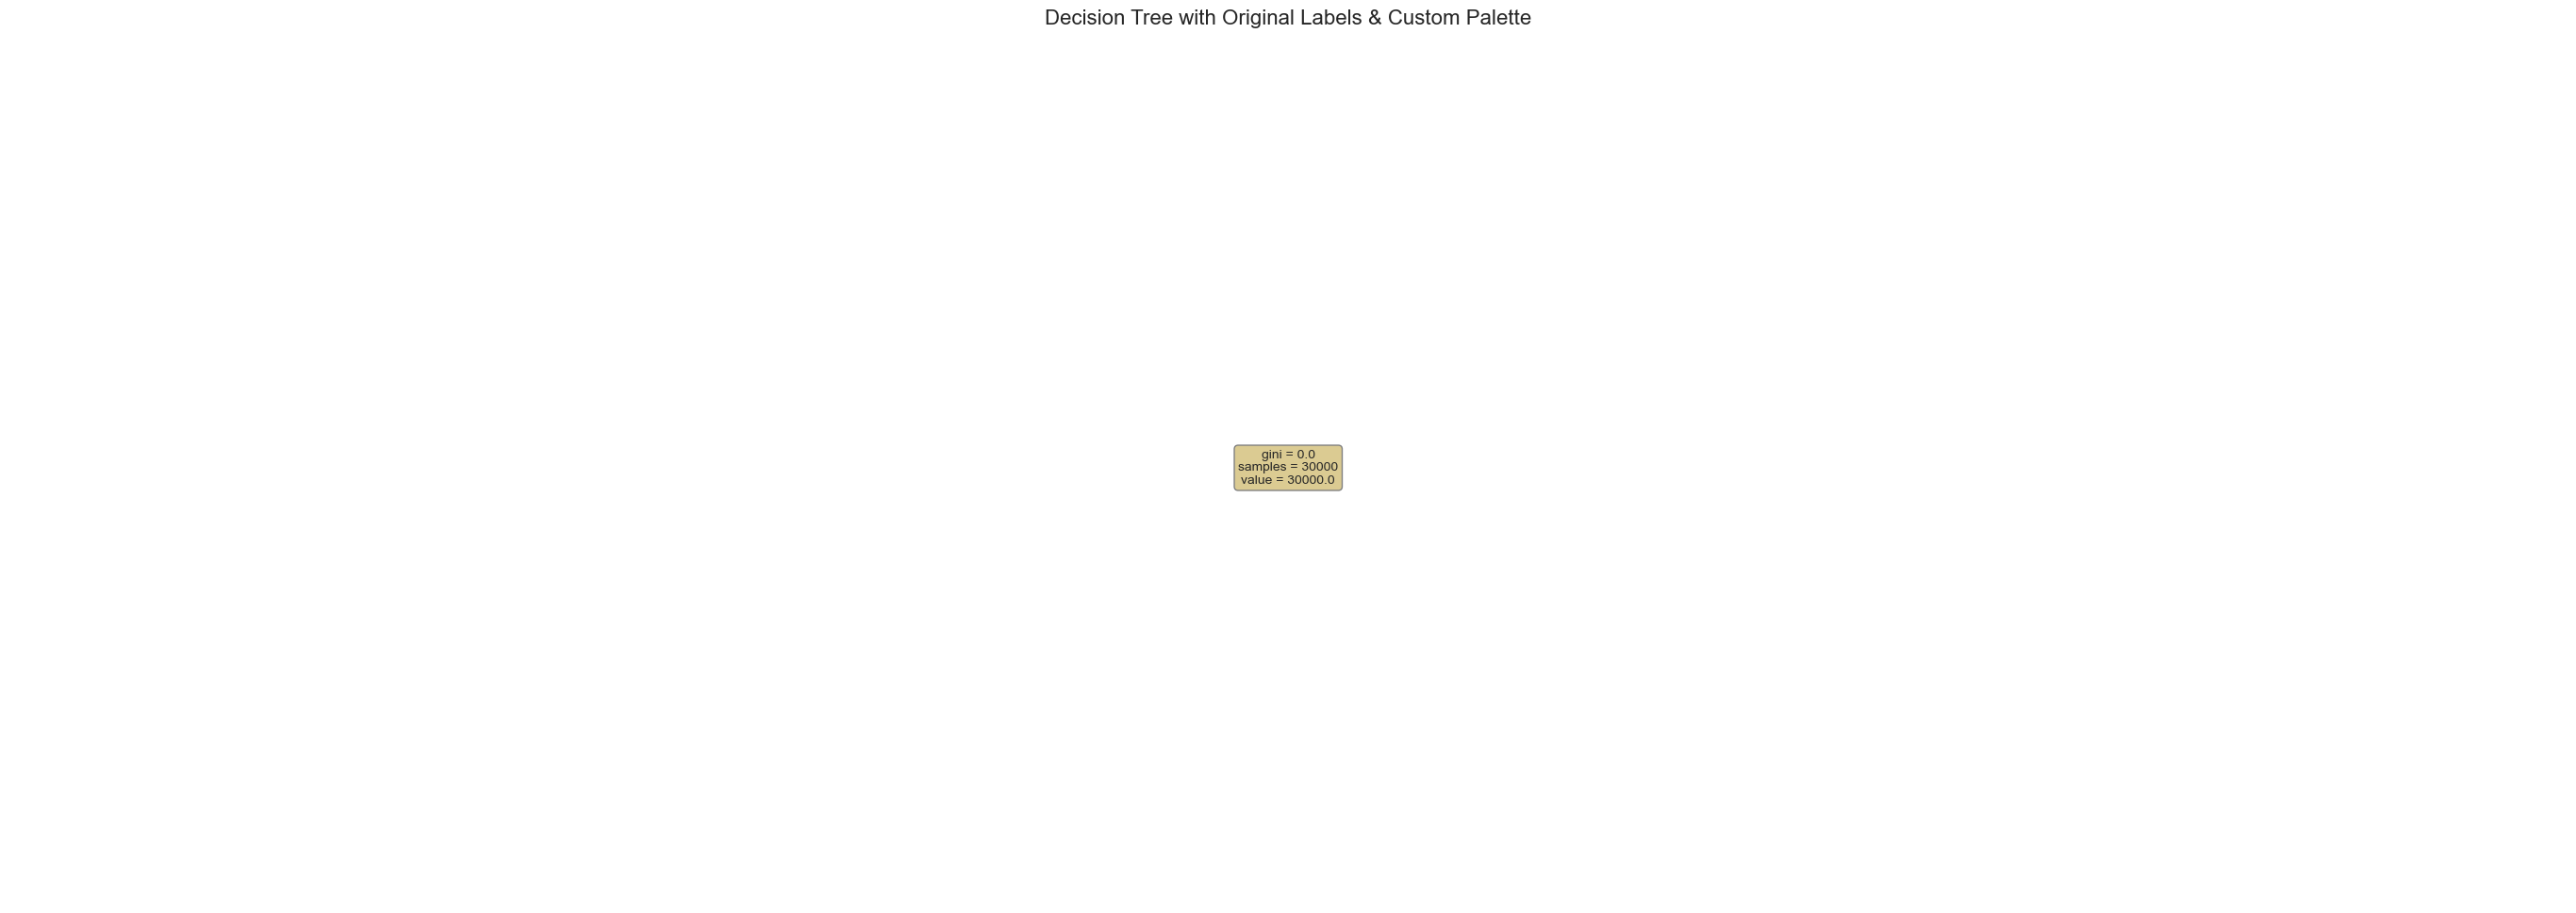

In [91]:
import re
plt.figure(figsize=(35, 12))
# 1. 正常绘图并获取返回的 artists
artists = plot_tree(dt, feature_names=input_features,
                    class_names=le_y.classes_,
                    filled=True, rounded=True, fontsize=10)

# 2. 遍历每个节点，替换编码值为原始标签
for artist in artists:
    text = artist.get_text()

    # 使用正则表达式匹配类似 "d <= 0.5" 或 "c <= 1.5" 的模式
    for col in input_features:
        pattern = rf"{col} <= ([\d\.]+)"
        match = re.search(pattern, text)

        if match:
            threshold = float(match.group(1))
            # 找到最接近该阈值的原始标签
            # 因为 LabelEncoder 是按字母排序分配 0, 1, 2...
            # <= 0.5 通常意味着索引为 0 的那个类别
            original_labels = le_dict[col].classes_
            idx = int(round(threshold))

            # 这里的逻辑：<= 0.5 指的是判断是否为第一个类别
            if idx < len(original_labels):
                label_val = original_labels[idx]
                new_text = text.replace(f"{col} <= {match.group(1)}", f"{col} is {label_val}?")
                artist.set_text(new_text)

    if "class = Accept" in text:
        artist.set_bbox(dict(facecolor='#7BC0CD', edgecolor='black', boxstyle='round,pad=0.3'))
    elif "class = Reject" in text:
        artist.set_bbox(dict(facecolor='#ED8D5A', edgecolor='black', boxstyle='round,pad=0.3'))
    else:
        artist.set_bbox(dict(facecolor='#DBCB92', edgecolor='grey', boxstyle='round,pad=0.3'))

plt.title("Decision Tree with Original Labels & Custom Palette", fontsize=16)
plt.show()

决策路径分析

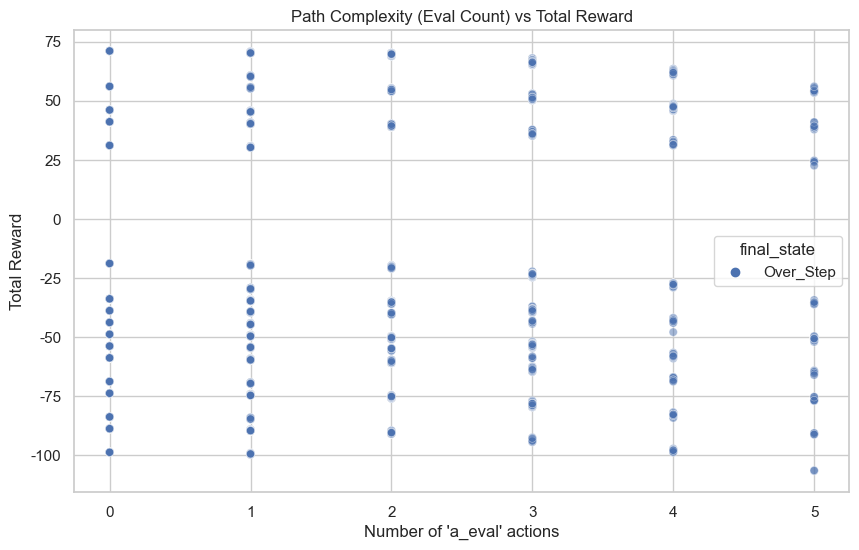

Decision Path Statistics by Final State:
             total_steps            total_reward
                   mean median max         mean
final_state                                    
Over_Step        5.0544    5.0   9   -19.158446


In [92]:
# 1. 提取路径复杂度：计算 a_eval 的次数
df['eval_count'] = df['actions_sequence'].str.count('a_eval')

# 2. 分析路径长度与奖励的关系
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='eval_count', y='total_reward', hue='final_state', alpha=0.5)
plt.title("Path Complexity (Eval Count) vs Total Reward")
plt.xlabel("Number of 'a_eval' actions")
plt.ylabel("Total Reward")
plt.show()

# 3. 统计不同结局的平均步数
path_stats = df.groupby('final_state').agg({
    'total_steps': ['mean', 'median', 'max'],
    'total_reward': 'mean'
})
print("Decision Path Statistics by Final State:\n", path_stats)

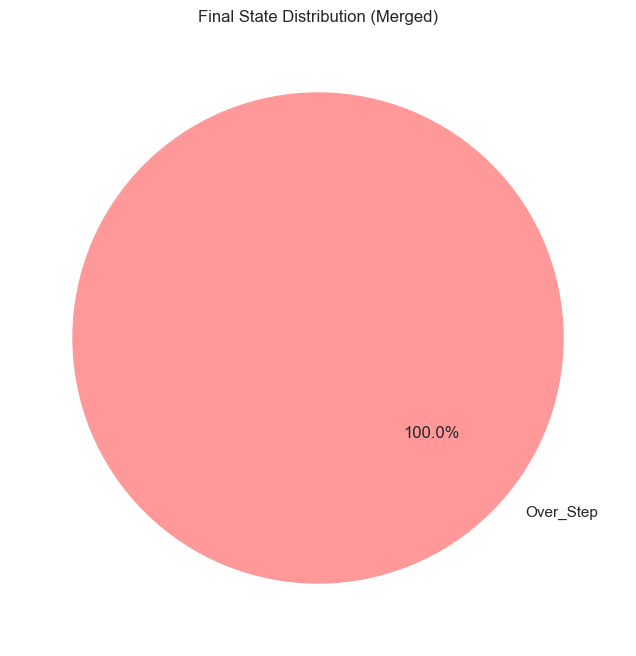

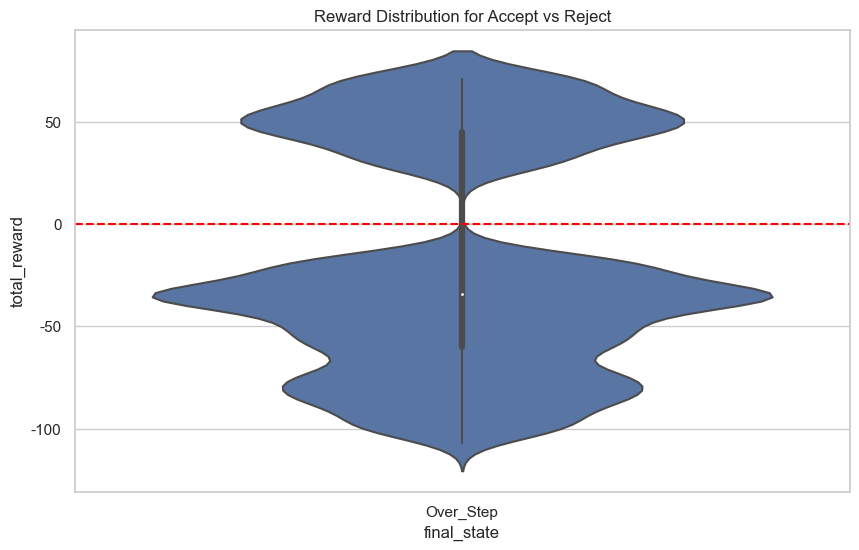

In [93]:
# 状态占比饼图
state_counts = df['final_state'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(state_counts, labels=state_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title("Final State Distribution (Merged)")
plt.show()

# 奖励密度分析 (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(x='final_state', y='total_reward', data=df)
plt.title("Reward Distribution for Accept vs Reject")
plt.axhline(0, color='red', linestyle='--') # 检查有多少决策是在 0 分以下的
plt.show()

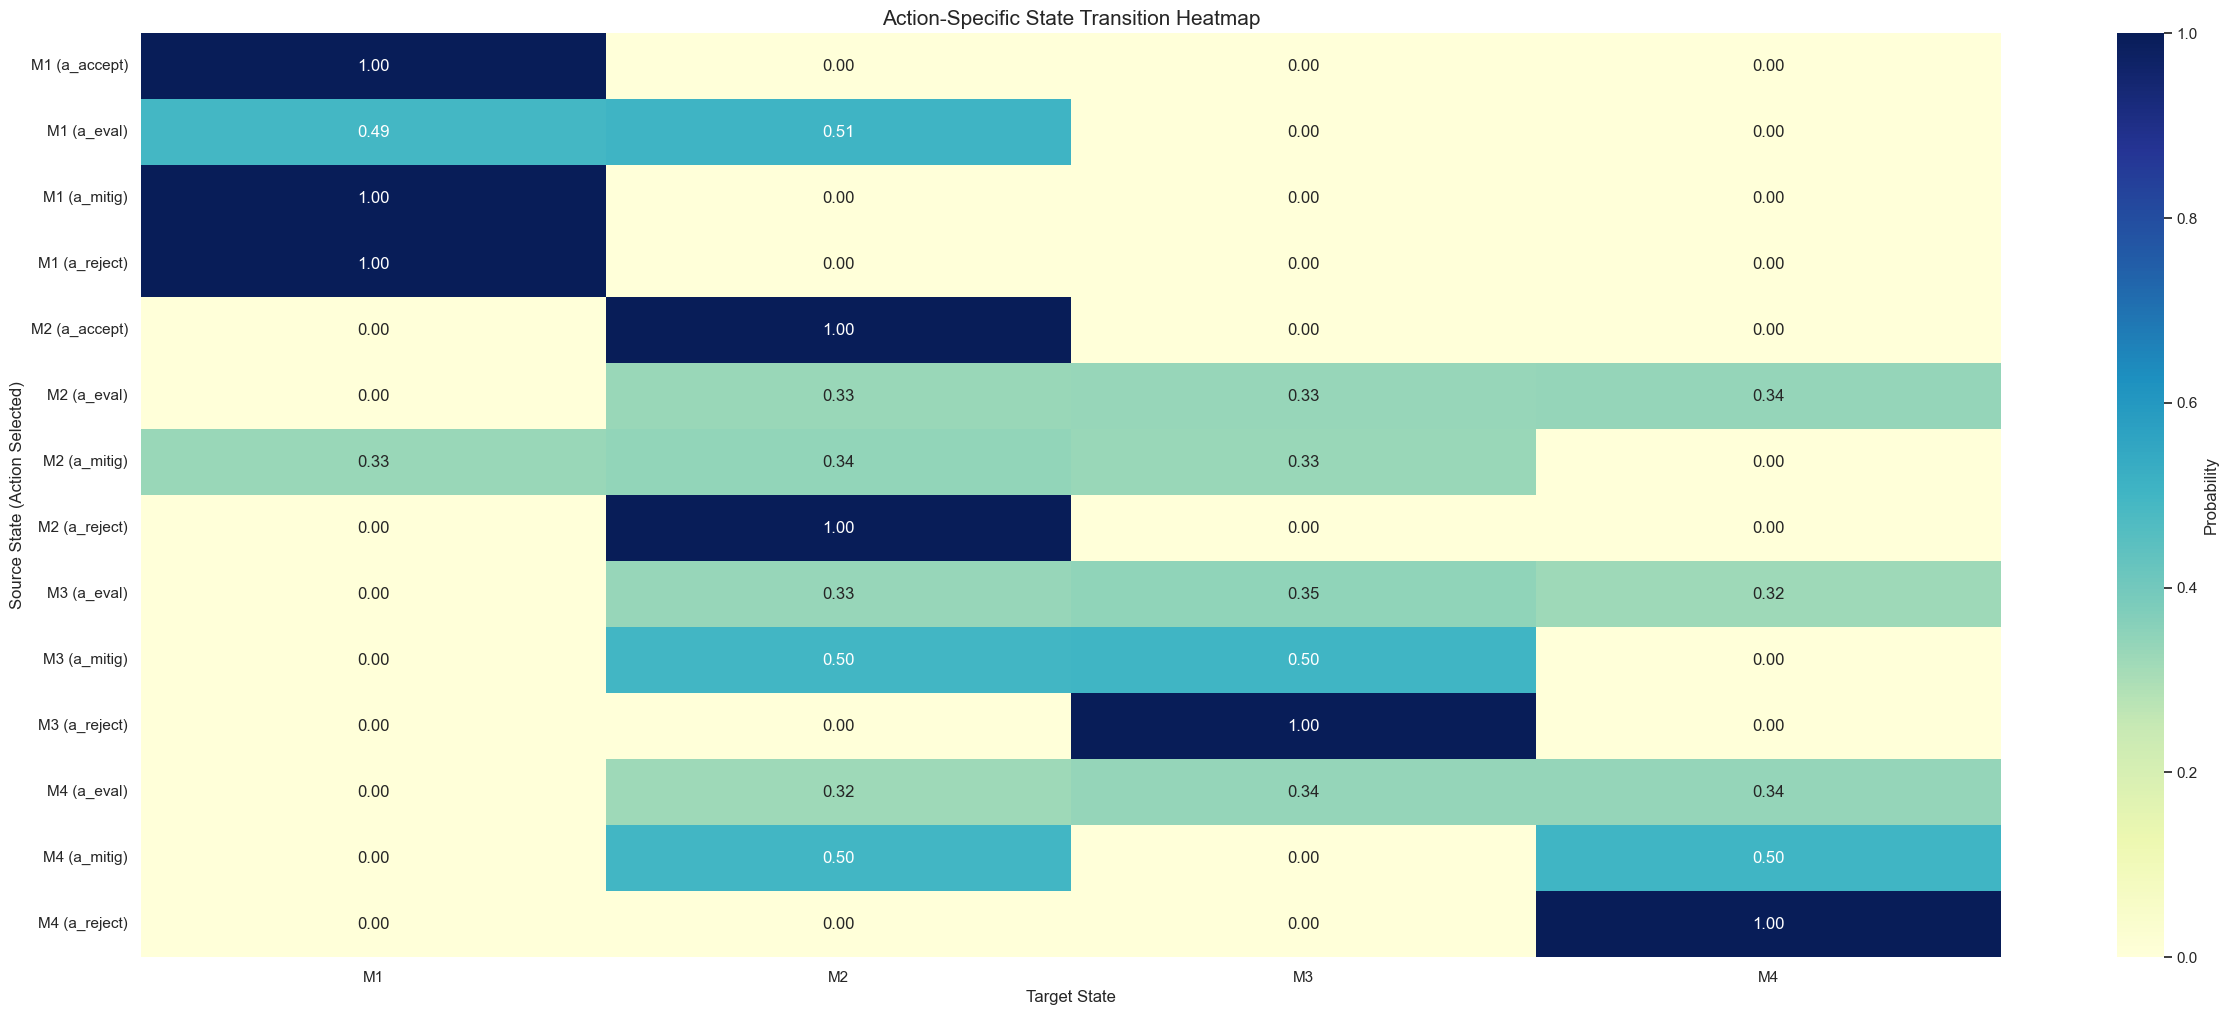

In [94]:
df = pd.read_csv("transition_v1.csv")
pivot_df = df.pivot(index=['current_state', 'action'], columns='next_state', values='probability').fillna(0)

def plot_transition_heatmap(df):
    # 创建组合标签
    df['state_action'] = df['current_state'] + " (" + df['action'] + ")"
    pivot_df = df.pivot(index='state_action', columns='next_state', values='probability').fillna(0)

    plt.figure(figsize=(30, 12))
    sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Probability'})
    plt.title("Action-Specific State Transition Heatmap", fontsize=15)
    plt.ylabel("Source State (Action Selected)")
    plt.xlabel("Target State")
    plt.show()

plot_transition_heatmap(df)

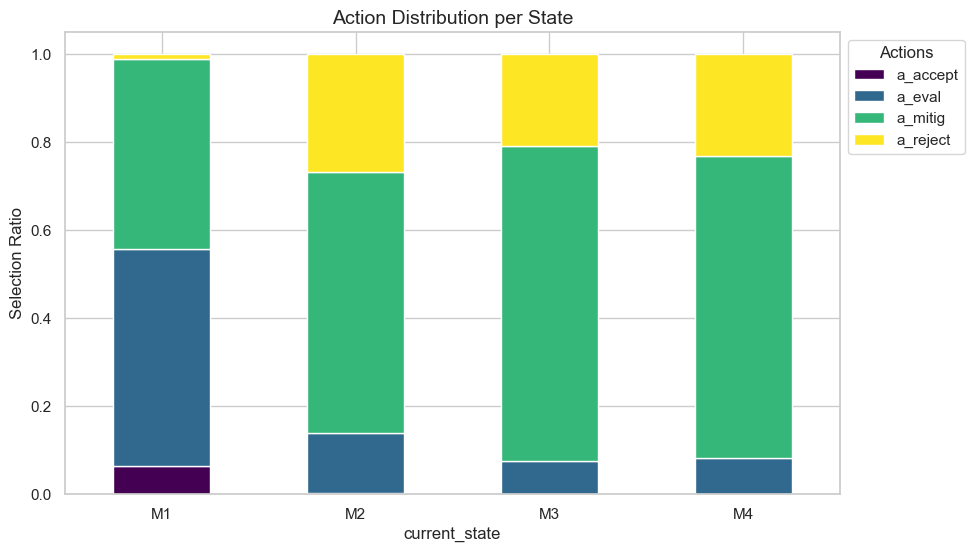

In [95]:
def plot_action_preference(df):
    # 计算每个状态下各动作的总次数
    action_counts = df.groupby(['current_state', 'action'])['count'].sum().unstack().fillna(0)
    # 归一化为百分比
    action_pct = action_counts.div(action_counts.sum(axis=1), axis=0)

    action_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap="viridis")
    plt.title("Action Distribution per State", fontsize=14)
    plt.ylabel("Selection Ratio")
    plt.legend(title="Actions", bbox_to_anchor=(1, 1))
    plt.xticks(rotation=0)
    plt.show()

plot_action_preference(df)

判断a_eval动作是否有用

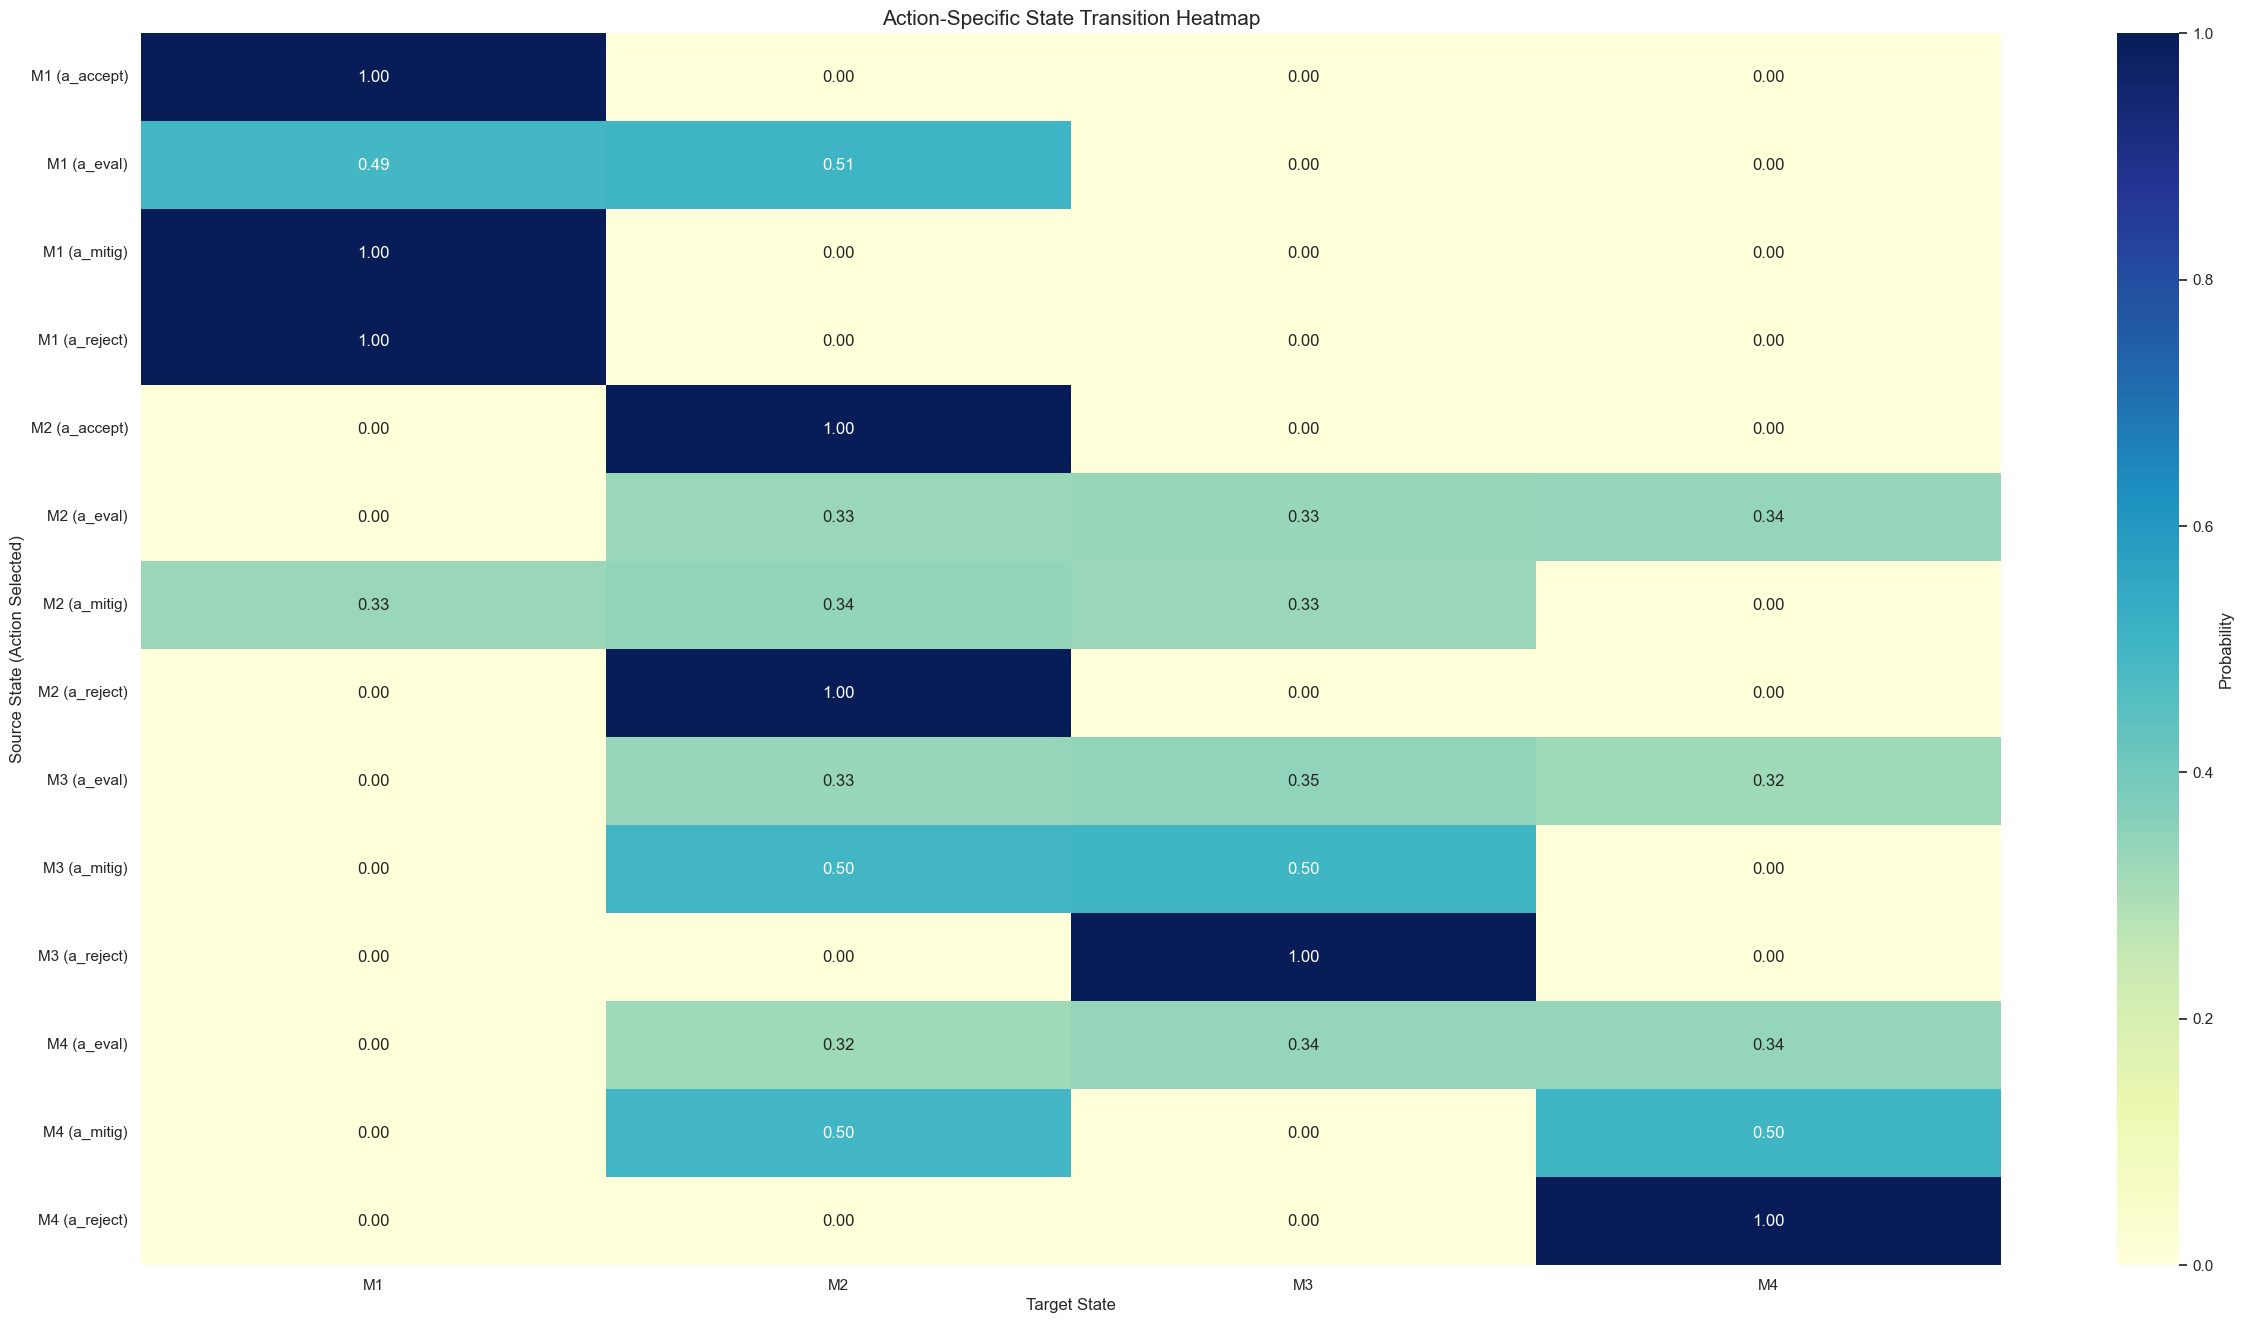

In [96]:
df = pd.read_csv("transition_v1.csv")
pivot_df = df.pivot(index=['current_state', 'action'], columns='next_state', values='probability').fillna(0)

def plot_transition_heatmap(df):
    # 创建组合标签
    df['state_action'] = df['current_state'] + " (" + df['action'] + ")"
    pivot_df = df.pivot(index='state_action', columns='next_state', values='probability').fillna(0)

    plt.figure(figsize=(30, 16))
    sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Probability'})
    plt.title("Action-Specific State Transition Heatmap", fontsize=15)
    plt.ylabel("Source State (Action Selected)")
    plt.xlabel("Target State")
    plt.show()

plot_transition_heatmap(df)

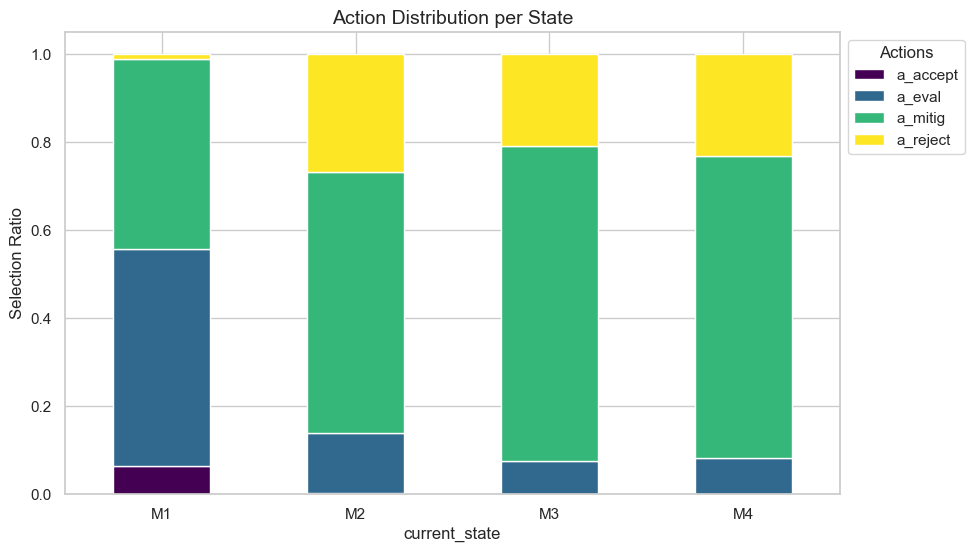

In [97]:
def plot_action_preference(df):
    # 计算每个状态下各动作的总次数
    action_counts = df.groupby(['current_state', 'action'])['count'].sum().unstack().fillna(0)
    # 归一化为百分比
    action_pct = action_counts.div(action_counts.sum(axis=1), axis=0)

    action_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap="viridis")
    plt.title("Action Distribution per State", fontsize=14)
    plt.ylabel("Selection Ratio")
    plt.legend(title="Actions", bbox_to_anchor=(1, 1))
    plt.xticks(rotation=0)
    plt.show()

plot_action_preference(df)

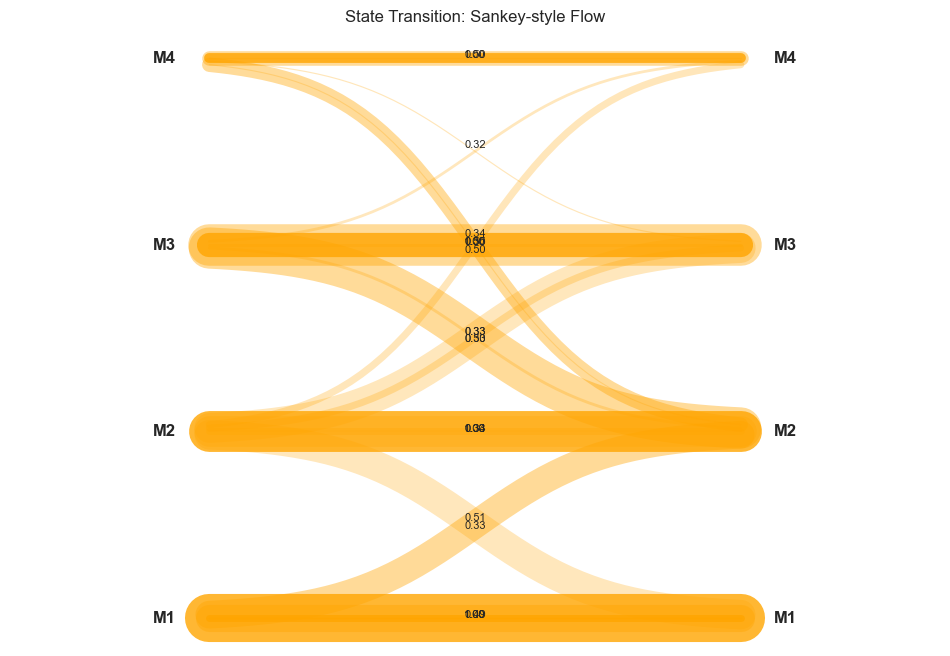

In [103]:
import numpy as np
df = pd.read_csv("transition_v1.csv")
def draw_sankey(df):
    plt.figure(figsize=(12, 8))
    curr_nodes = sorted(df['current_state'].unique())
    next_nodes = sorted(df['next_state'].unique())
    all_nodes = sorted(list(set(curr_nodes) | set(next_nodes)))
    y_map = {node: i for i, node in enumerate(all_nodes)}

    for _, row in df.iterrows():
        x = [0.1, 0.9]
        y = [y_map[row['current_state']], y_map[row['next_state']]]
        # 使用 sigmoid 曲线模拟流向
        x_fine = np.linspace(0.1, 0.9, 50)
        y_fine = y[0] + (y[1]-y[0]) * (1 / (1 + np.exp(-10 * (x_fine-0.5))))
        plt.plot(x_fine, y_fine, alpha=row['probability']*0.8, linewidth=row['count']/500, color='orange')

        if row['count'] > 500: # 仅标注主要概率
            plt.text(0.5, y_fine[25], f"{row['probability']:.2f}", fontsize=8, ha='center')

    for node in all_nodes:
        plt.text(0.05, y_map[node], node, ha='right', va='center', fontweight='bold')
        plt.text(0.95, y_map[node], node, ha='left', va='center', fontweight='bold')

    plt.title("State Transition: Sankey-style Flow")
    plt.xlim(-0.2, 1.2)
    plt.axis('off')
    plt.show()
    # plt.savefig('sankey.png')
draw_sankey(df)

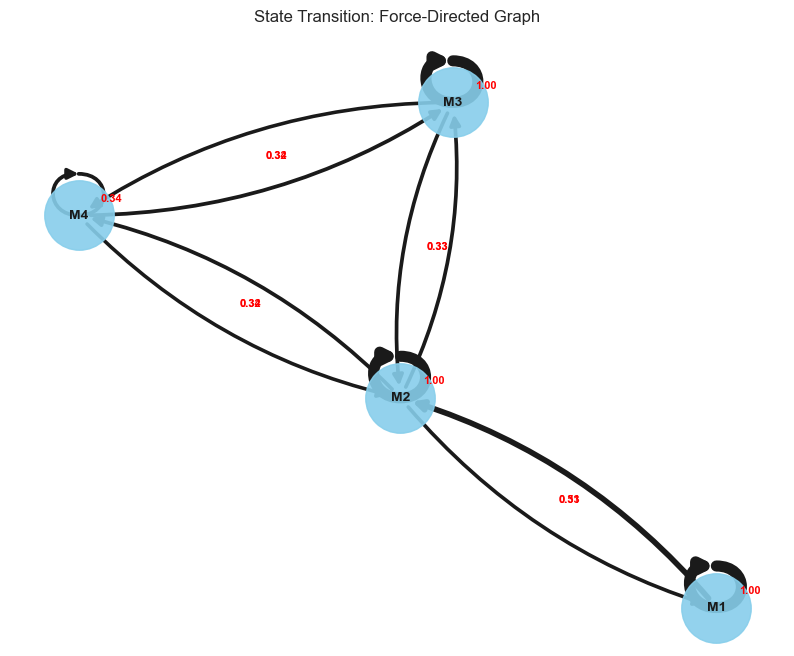

In [104]:
import networkx as nx
def draw_force_directed(df):
    G = nx.DiGraph()
    for _, row in df.iterrows():
        G.add_edge(row['current_state'], row['next_state'], weight=row['probability'], action=row['action'])

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=3, iterations=100)

    nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='skyblue', alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # 绘制带弧度的连线，避免重叠
    for (u, v, d) in G.edges(data=True):
        rad = 0.15 if u != v else 0.4
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=d['weight']*8,
                               connectionstyle=f"arc3,rad={rad}", arrowstyle='-|>', arrowsize=15)

        # 标注转移概率
        mid = (pos[u] + pos[v]) / 2 + (0.05 if u==v else 0)
        plt.text(mid[0], mid[1], f"{d['weight']:.2f}", color='red', fontsize=8, fontweight='bold')

    plt.title("State Transition: Force-Directed Graph")
    plt.axis('off')
draw_force_directed(df)

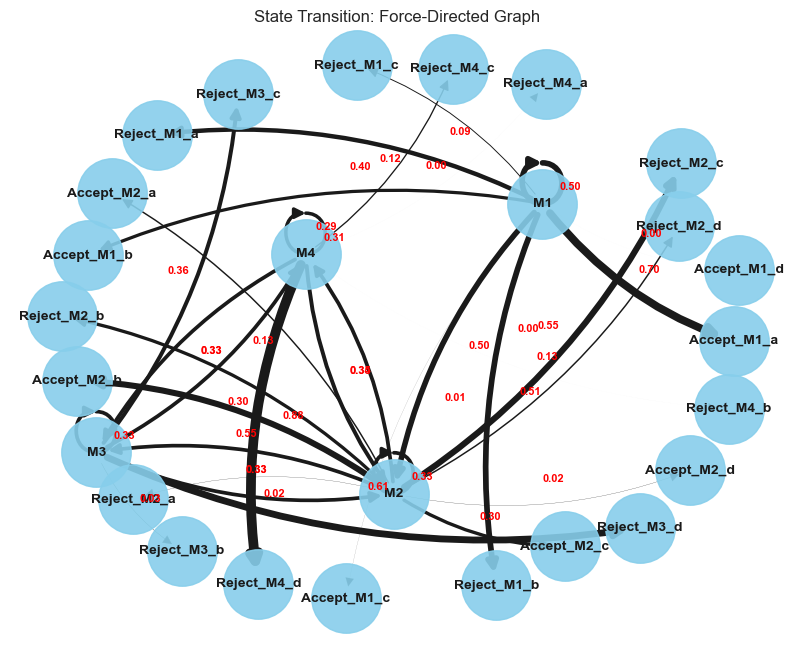

In [105]:
df = pd.read_csv("transition_v7.csv")
draw_force_directed(df)

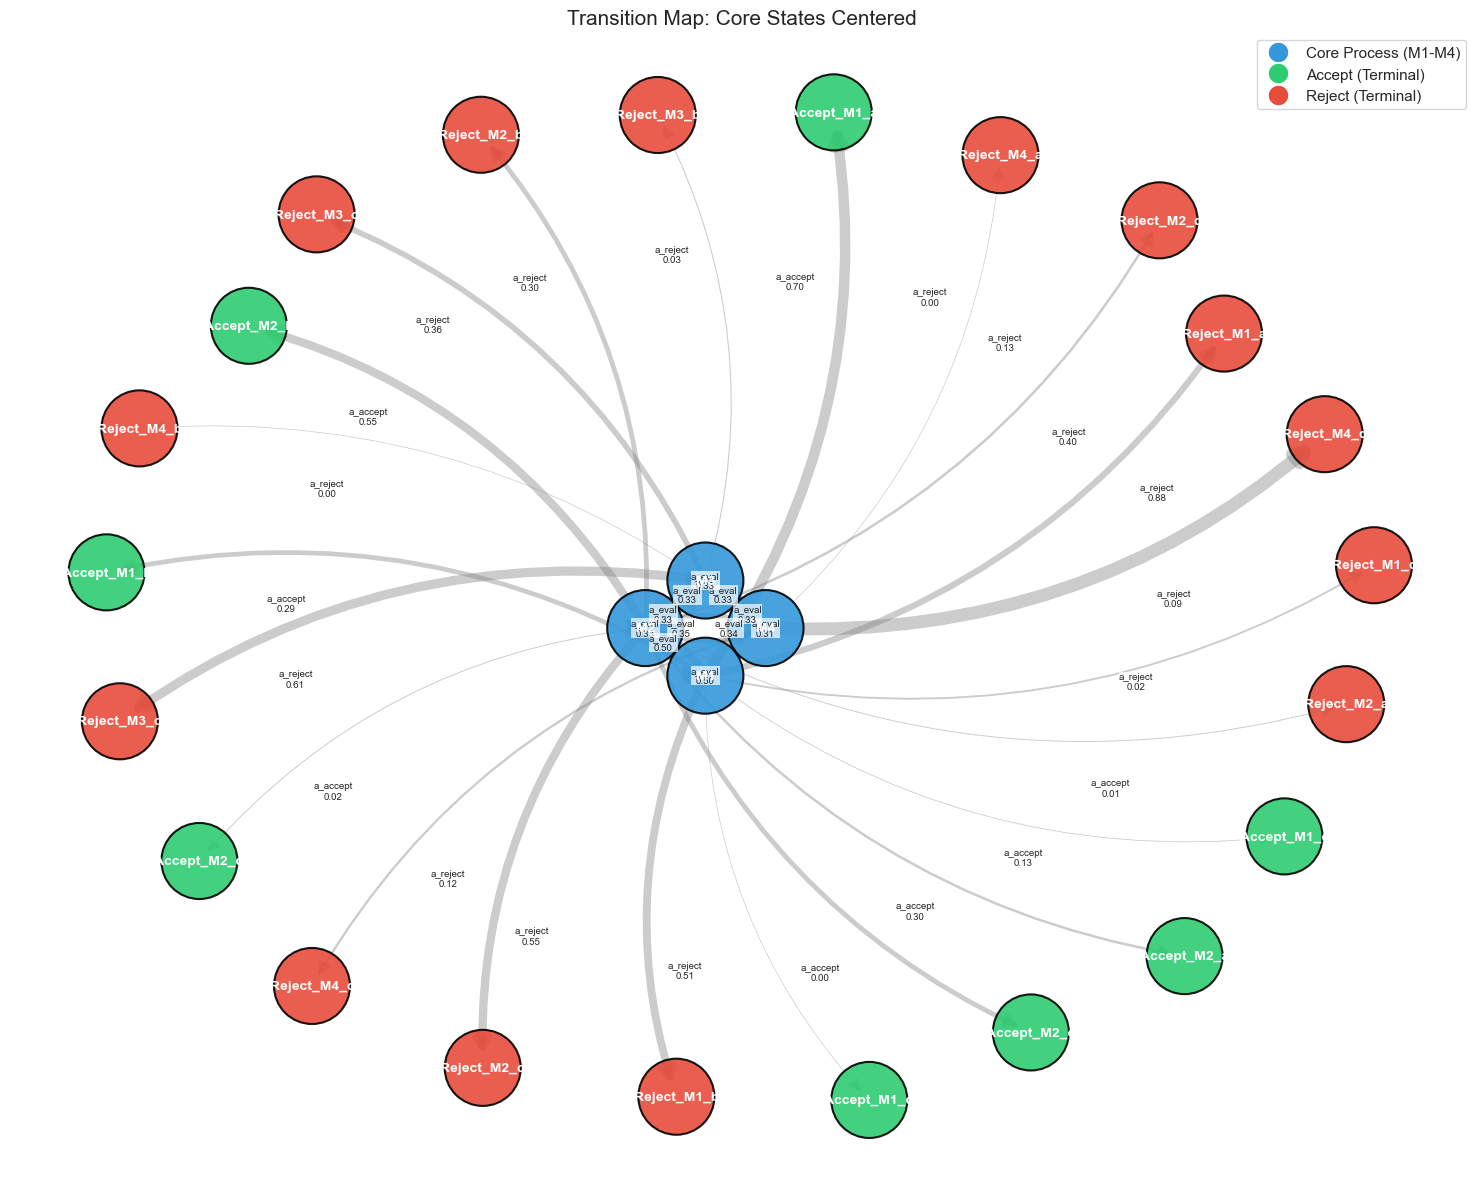

In [117]:
def get_node_color(node):
    if node.startswith('M'): return '#3498db'
    if 'Accept' in node: return '#2ecc71'
    if 'Reject' in node: return '#e74c3c'
    return '#95a5a6'

def draw_centered_force_directed(df):
    G = nx.MultiDiGraph()
    for _, row in df.iterrows():
        G.add_edge(row['current_state'], row['next_state'], weight=row['probability'], action=row['action'])

    # --- 核心逻辑：定义固定位置 ---
    all_nodes = list(G.nodes())
    core_nodes = [n for n in all_nodes if n.startswith('M')]
    outer_nodes = [n for n in all_nodes if n not in core_nodes]

    # 1. 将 M 节点手动固定在中心的一个小圆圈内
    # 使用 circular_layout 仅针对核心点，缩放比例设小 (如 0.3)
    core_pos = nx.circular_layout(core_nodes, scale=10)

    # 2. 使用 spring_layout 计算外部节点位置，但固定核心节点坐标
    # pos 参数传入初始坐标，fixed 参数指定哪些点不动
    pos = nx.spring_layout(G, pos=core_pos, fixed=core_nodes, k=2, iterations=100, seed=42)

    plt.figure(figsize=(15, 12))
    ax = plt.gca()

    # 绘制连线
    for (u, v, key, d) in G.edges(keys=True, data=True):
        # 自环弧度大，核心间连线弧度小
        rad = 3 if u == v else 0.2
        width = d['weight'] * 10 + 0.5

        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)],
                               width=width,
                               connectionstyle=f"arc3,rad={rad}",
                               edge_color='gray', alpha=0.4,
                               arrowstyle='-|>', arrowsize=20)

        # 标注 Action 和 Probability
        p1, p2 = np.array(pos[u]), np.array(pos[v])
        txt_pos = (p1 * 0.3 + p2 * 0.7) # 将文字稍微靠向终点，减少中心区域拥挤

        plt.text(txt_pos[0], txt_pos[1], f"{d['action']}\n{d['weight']:.2f}",
                 fontsize=7, ha='center', va='center',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.1))

    # 绘制节点
    node_colors = [get_node_color(n) for n in all_nodes]
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color=node_colors,
                           edgecolors='black', linewidths=1.5, alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='white')

    # 图例
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Core Process (M1-M4)', markerfacecolor='#3498db', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='Accept (Terminal)', markerfacecolor='#2ecc71', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='Reject (Terminal)', markerfacecolor='#e74c3c', markersize=15)
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.title("Transition Map: Core States Centered", fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_centered_force_directed(df)